# Customer Churn Prediction

**Pipeline:** EDA → Preprocessing → 5 Models đơn lẻ → Voting Ensemble → SHAP Explainability

**Dataset:** IBM Telco Customer Churn (7.043 khách hàng, 21 features)

---
| Pha | Nội dung |
|-----|----------|
| 1 | Cài đặt & Load data |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Tiền xử lý & Feature Engineering |
| 4 | Huấn luyện 5 mô hình đơn lẻ |
| 5 | Đánh giá & So sánh models |
| 6 | Voting Ensemble (Hard + Soft) |
| 7 | Giải thích mô hình với SHAP |
| 8 | Dự đoán khách hàng mới |

## PHA 1 — CÀI ĐẶT THƯ VIỆN

In [3]:
!pip install shap imbalanced-learn xgboost lightgbm --quiet
print('✅ Đã cài xong tất cả thư viện')

✅ Đã cài xong tất cả thư viện


In [33]:
# ============================================================
# IMPORT & SEED
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import shap
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

COLORS = {'churn': '#E8593C', 'no_churn': '#1D9E75', 'accent': '#3266ad'}
print('✅ Import xong, seed =', SEED)


✅ Import xong, seed = 42


In [5]:
# ============================================================
# LOAD DATA — dùng MỘT nguồn dữ liệu cho cả notebook
# ============================================================

def load_data(path):
  """Đọc CSV từ đường dẫn local hoặc file vừa upload."""
  df = pd.read_csv(path)
  return df

def validate_schema(df):
  """Kiểm tra và in thông tin cơ bản."""
  if 'Churn' not in df.columns:
    raise ValueError("Dataset phải có cột 'Churn'")

  # Chuẩn hóa nhãn nếu là Yes/No
  if df['Churn'].dtype == object:
    df = df.copy()
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})

  print(f'Shape: {df.shape[0]:,} hàng × {df.shape[1]} cột')
  print(f'Churn rate: {df["Churn"].mean():.1%}')

  missing = df.isnull().sum()
  if missing.sum() > 0:
    print('\nMissing values:')
    print(missing[missing > 0])
  else:
    print('Không có missing values')

  return df

# --- Chọn 1 trong 2 cách load ---

# CÁCH A: Google Colab (upload)
try:
  from google.colab import files
  print('Vui lòng upload file CSV:')
  uploaded = files.upload()
  file_name = next(iter(uploaded))
  print(f'Đã upload: {file_name}')
except ImportError:
  # CÁCH B: Chạy local — đặt file CSV cùng thư mục hoặc sửa đường dẫn
  file_name = os.getenv('CHURN_DATA_PATH', 'Dataset.csv')
  print(f'Dùng file local: {file_name}')

df_raw = load_data(file_name)
df_raw = validate_schema(df_raw)

# Loại cột ID ngay từ đầu (tránh dùng nhầm ở EDA)
if 'Customer_number' in df_raw.columns:
  df_raw = df_raw.drop(columns=['Customer_number'])

df_raw.head()

Vui lòng upload file CSV:


Saving Dataset.csv to Dataset (1).csv
Đã upload: Dataset (1).csv
Shape: 66,736 hàng × 30 cột
Churn rate: 35.0%
Không có missing values


,Client_gender,Age,Staff_VIB,Tenure,SMS,Verify_method,EB_register_channel,No_Activity_Name,Type_Transactions,Total_trans_no,...,Avg_TermDeposit_Balance,Max_TermDeposit_Balance,Min_TermDeposit_Balance,No_Loan,Avg_Loan_Balance,Max_Loan_Balance,Min_Loan_Balance,No_CC,No_DC,Churn
0,0,28.215615,1,19.918800,0,1,0,1,7,639.227581,...,2.778291e+07,4.297395e+07,8.143434e+05,4,2.134182e+07,3.628493e+07,6.139306e+06,1,0,0
1,1,28.744430,0,8.076794,1,0,0,11,3,172.259608,...,1.020093e+06,1.323149e+06,2.380507e+04,0,2.519806e+06,3.799277e+06,7.046202e+05,0,2,1
2,0,35.406264,0,11.641340,0,1,0,8,6,235.655544,...,3.301211e+06,4.550049e+06,9.072812e+05,0,1.389617e+07,2.167573e+07,2.676174e+06,1,0,1
3,1,31.186114,0,22.163064,1,1,2,13,5,596.578450,...,5.901529e+06,1.177052e+07,6.160315e+05,4,2.126704e+07,2.609320e+07,1.665175e+06,2,0,0
4,0,42.555118,0,21.800850,0,0,0,6,8,643.828134,...,3.607055e+07,4.406522e+07,5.763604e+06,1,4.620992e+07,6.357315e+07,1.049171e+07,0,0,0


## 📊 Pha 2 — Exploratory Data Analysis (EDA)

In [6]:
# ============================================================
# PHASE 0 — DATA OVERVIEW & QUALITY CHECK
# ============================================================
print("Shape:", df_raw.shape)
print("\n--- Dtypes ---")
print(df_raw.dtypes)

print("\n--- Missing values ---")
miss = df_raw.isnull().sum()
print(miss[miss > 0] if miss.sum() > 0 else "Không có missing value")

print("\n--- Duplicates ---")
print(df_raw.duplicated().sum())

print("\n--- Describe (numeric) ---")
display(df_raw.describe().T)

cols_to_drop = [c for c in ['Customer_number', 'Churn'] if c in df_raw.columns]
num_cols_all = df_raw.select_dtypes(include=[np.number]).columns.drop(cols_to_drop)
skew_kurt = pd.DataFrame({
    'skewness': df_raw[num_cols_all].skew(),
    'kurtosis': df_raw[num_cols_all].kurt()
}).sort_values('skewness', ascending=False)
print("\n--- Skewness & Kurtosis ---")
display(skew_kurt)

print(f"\nChurn rate: {df_raw['Churn'].mean()*100:.2f}%")

Shape: (66736, 29)

--- Dtypes ---
Client_gender                   int64
Age                           float64
Staff_VIB                       int64
Tenure                        float64
SMS                             int64
Verify_method                   int64
EB_register_channel             int64
No_Activity_Name                int64
Type_Transactions               int64
Total_trans_no                float64
Avg_Trans_no_month            float64
Avg_Trans_Amount              float64
Max_Trans_Amount              float64
Min_Trans_Amount              float64
No_CurrentAccount               int64
Avg_CurrentAccount_Balance    float64
Max_CurrentAccount_Balance    float64
Min_CurrentAccount_Balance    float64
No_TermDeposit                  int64
Avg_TermDeposit_Balance       float64
Max_TermDeposit_Balance       float64
Min_TermDeposit_Balance       float64
No_Loan                         int64
Avg_Loan_Balance              float64
Max_Loan_Balance              float64
Min_Loan_Balanc

,count,mean,std,min,25%,50%,75%,max
Client_gender,66736.0,5.502427e-01,4.974730e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
Age,66736.0,3.515529e+01,9.588401e+00,1.800000e+01,2.824645e+01,3.497313e+01,4.168500e+01,7.500000e+01
Staff_VIB,66736.0,4.905898e-02,2.159928e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
Tenure,66736.0,1.224122e+01,7.241866e+00,5.000000e-01,6.834017e+00,1.205670e+01,1.723238e+01,4.421932e+01
SMS,66736.0,3.979112e-01,4.894706e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
Verify_method,66736.0,9.015824e-01,5.391067e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00
EB_register_channel,66736.0,7.959872e-01,8.708921e-01,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,2.000000e+00
No_Activity_Name,66736.0,7.512962e+00,4.036339e+00,1.000000e+00,4.000000e+00,8.000000e+00,1.100000e+01,1.400000e+01
Type_Transactions,66736.0,5.013756e+00,2.577857e+00,1.000000e+00,3.000000e+00,5.000000e+00,7.000000e+00,9.000000e+00
Total_trans_no,66736.0,2.974812e+02,2.629313e+02,1.000000e+00,9.408992e+01,2.345810e+02,4.333653e+02,2.217992e+03



--- Skewness & Kurtosis ---


,skewness,kurtosis
Staff_VIB,4.175644,15.436465
Min_Loan_Balance,2.997134,14.780603
Min_TermDeposit_Balance,2.986129,13.468181
Max_TermDeposit_Balance,2.563574,10.762858
Max_Loan_Balance,2.457769,9.653661
Min_CurrentAccount_Balance,2.444759,9.394094
Avg_TermDeposit_Balance,2.351203,8.611552
Avg_Loan_Balance,2.271920,7.771809
Max_CurrentAccount_Balance,1.900331,5.477566
Avg_CurrentAccount_Balance,1.780369,4.602562



Churn rate: 35.00%


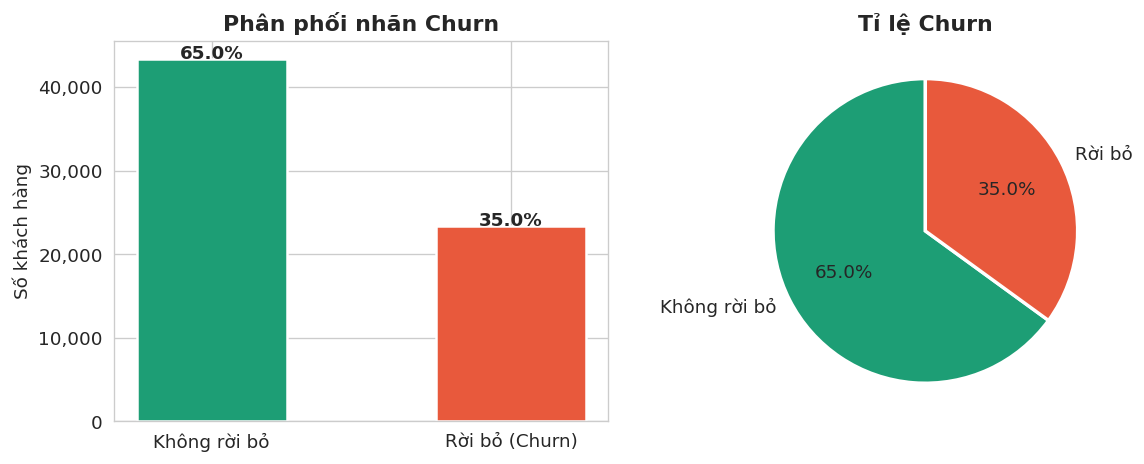

⚠️  Dữ liệu mất cân bằng: 35.0% churn → cần SMOTE ở bước preprocessing


In [7]:
def plot_churn_distribution(df):
    """Phân phối nhãn Churn: count + pie chart."""
    counts = df['Churn'].value_counts()
    pct    = df['Churn'].value_counts(normalize=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Bar
    bars = axes[0].bar(
        ['Không rời bỏ', 'Rời bỏ (Churn)'],
        counts.values,
        color=[COLORS['no_churn'], COLORS['churn']],
        edgecolor='white', linewidth=1.5, width=0.5
    )
    for bar, p in zip(bars, pct.values):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 60,
                     f'{p:.1f}%', ha='center', fontweight='bold')
    axes[0].set_title('Phân phối nhãn Churn', fontweight='bold')
    axes[0].set_ylabel('Số khách hàng')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Pie
    axes[1].pie(
        counts.values,
        labels=['Không rời bỏ', 'Rời bỏ'],
        colors=[COLORS['no_churn'], COLORS['churn']],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    axes[1].set_title('Tỉ lệ Churn', fontweight='bold')

    plt.tight_layout()
    plt.savefig('eda_churn_dist.png', bbox_inches='tight')
    plt.show()
    churn_pct = df['Churn'].mean() * 100
    print(f'⚠️  Dữ liệu mất cân bằng: {churn_pct:.1f}% churn → cần SMOTE ở bước preprocessing')
plot_churn_distribution(df_raw)

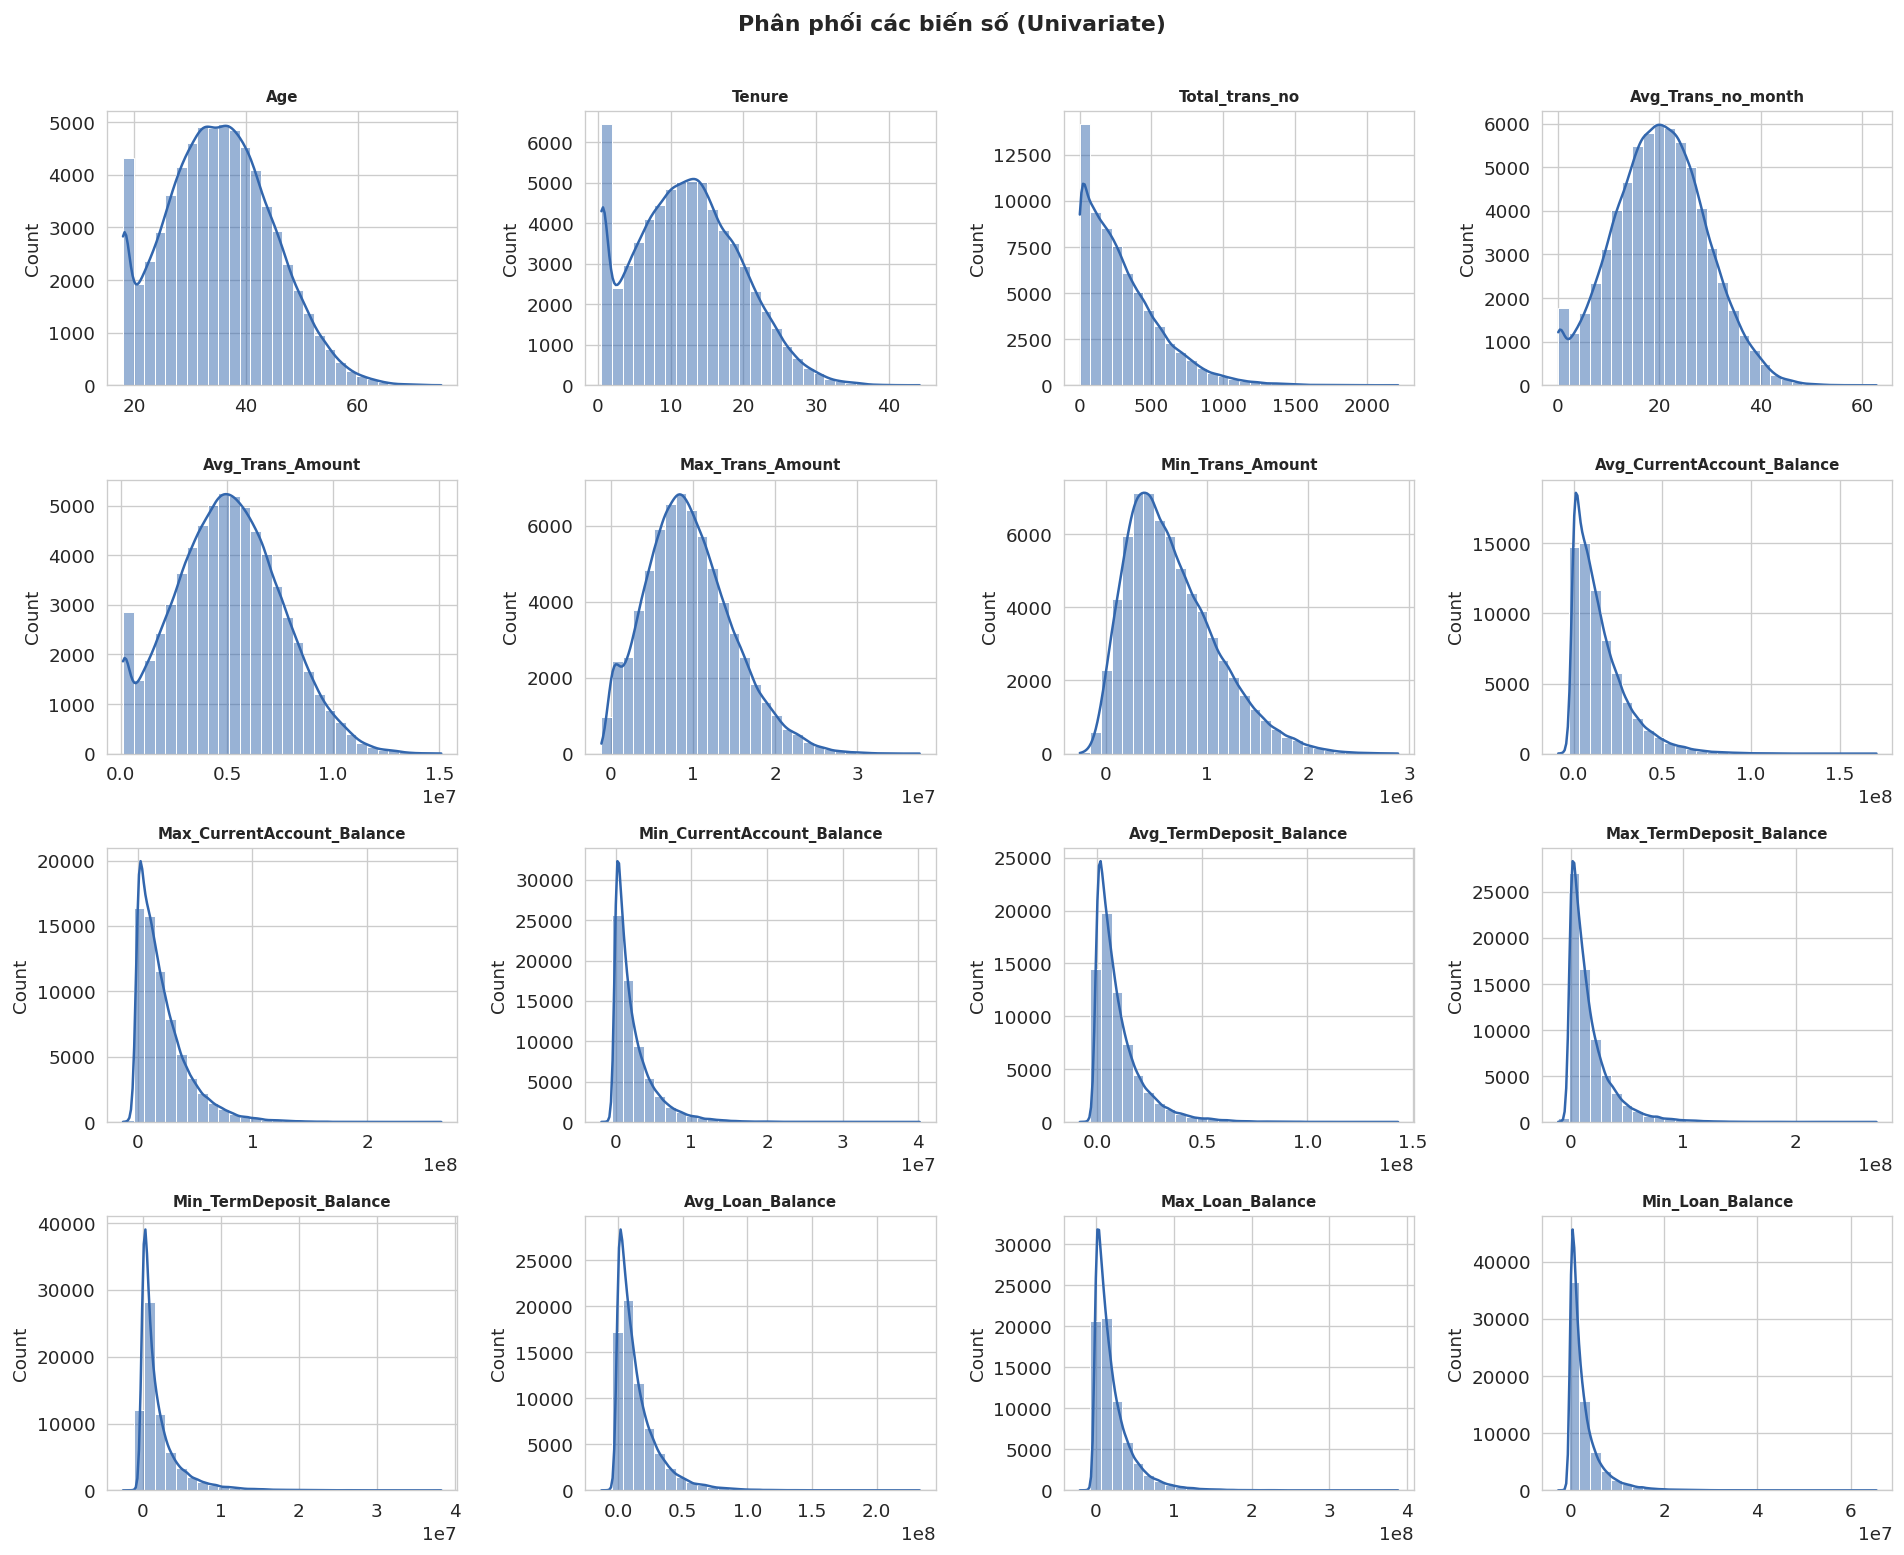

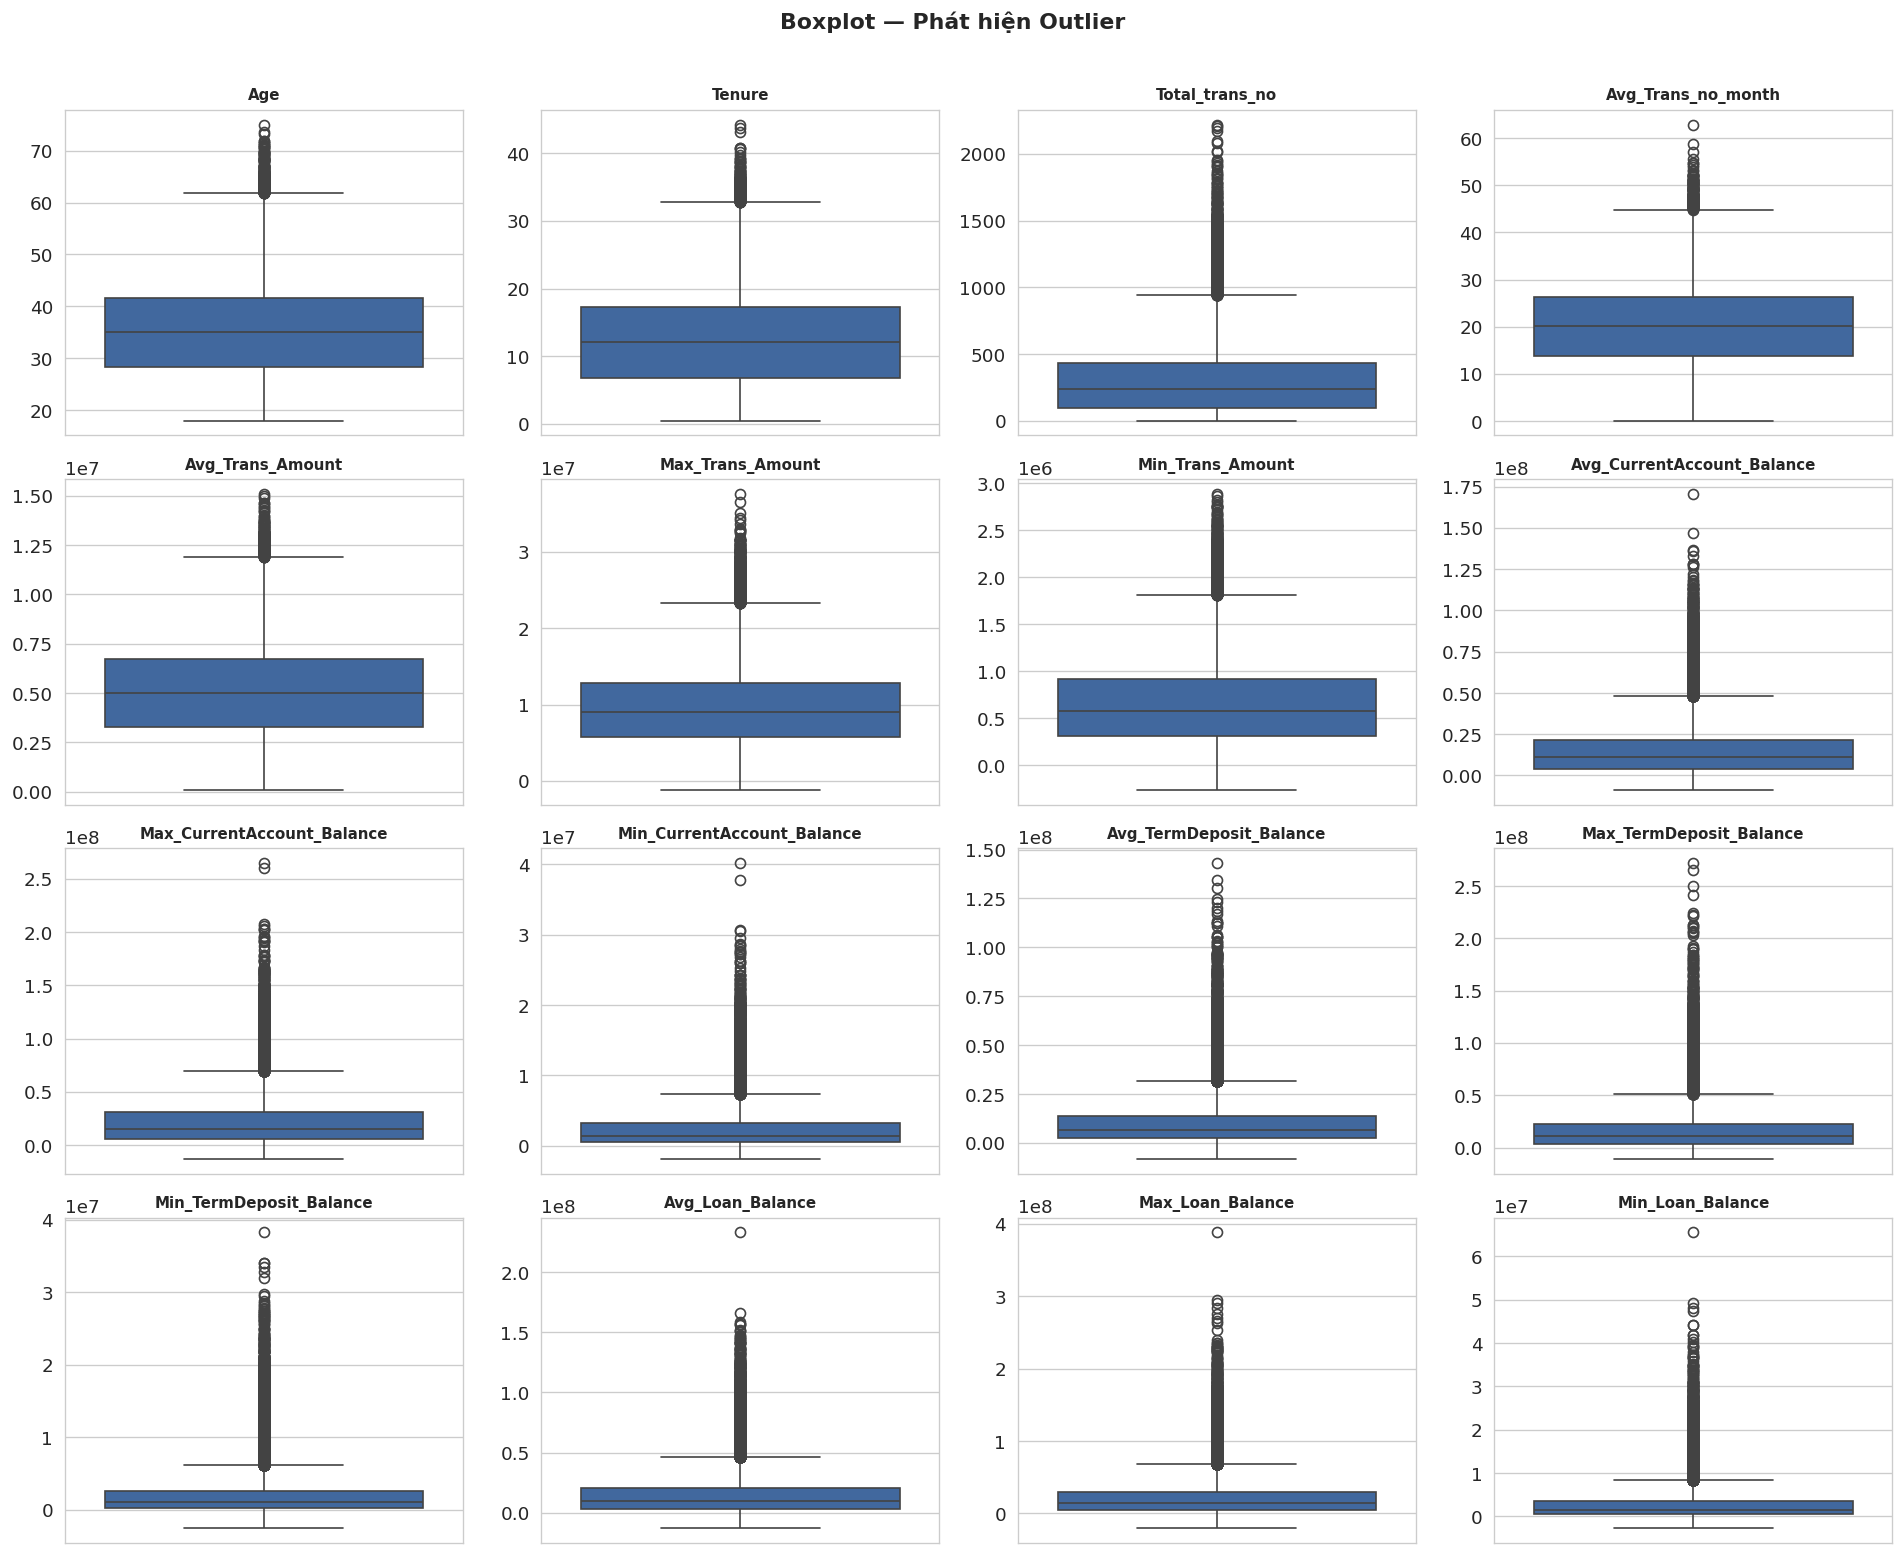

In [8]:
# ============================================================
# PHASE 1 — UNIVARIATE ANALYSIS
# ============================================================
continuous_cols = ['Age','Tenure','Total_trans_no','Avg_Trans_no_month',
                    'Avg_Trans_Amount','Max_Trans_Amount','Min_Trans_Amount',
                    'Avg_CurrentAccount_Balance','Max_CurrentAccount_Balance','Min_CurrentAccount_Balance',
                    'Avg_TermDeposit_Balance','Max_TermDeposit_Balance','Min_TermDeposit_Balance',
                    'Avg_Loan_Balance','Max_Loan_Balance','Min_Loan_Balance']

categorical_cols = ['Client_gender','Staff_VIB','SMS','Verify_method','EB_register_channel',
                     'No_Activity_Name','Type_Transactions',
                     'No_CurrentAccount','No_TermDeposit','No_Loan','No_CC','No_DC']

def plot_univariate_numeric(df, cols, ncols=4):
    n = len(cols); nrows = int(np.ceil(n/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3.2))
    axes = axes.flatten()
    for ax, col in zip(axes, cols):
        sns.histplot(df[col], bins=30, kde=True, color=COLORS['accent'], ax=ax)
        ax.set_title(col, fontsize=9, fontweight='bold'); ax.set_xlabel('')
    for ax in axes[n:]: ax.axis('off')
    plt.suptitle('Phân phối các biến số (Univariate)', fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('eda_univariate_numeric.png', bbox_inches='tight'); plt.show()

def plot_univariate_boxplot(df, cols, ncols=4):
    n = len(cols); nrows = int(np.ceil(n/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3.2))
    axes = axes.flatten()
    for ax, col in zip(axes, cols):
        sns.boxplot(y=df[col], color=COLORS['accent'], ax=ax)
        ax.set_title(col, fontsize=9, fontweight='bold'); ax.set_ylabel('')
    for ax in axes[n:]: ax.axis('off')
    plt.suptitle('Boxplot — Phát hiện Outlier', fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('eda_univariate_boxplot.png', bbox_inches='tight'); plt.show()

plot_univariate_numeric(df_raw, continuous_cols)
plot_univariate_boxplot(df_raw, continuous_cols)

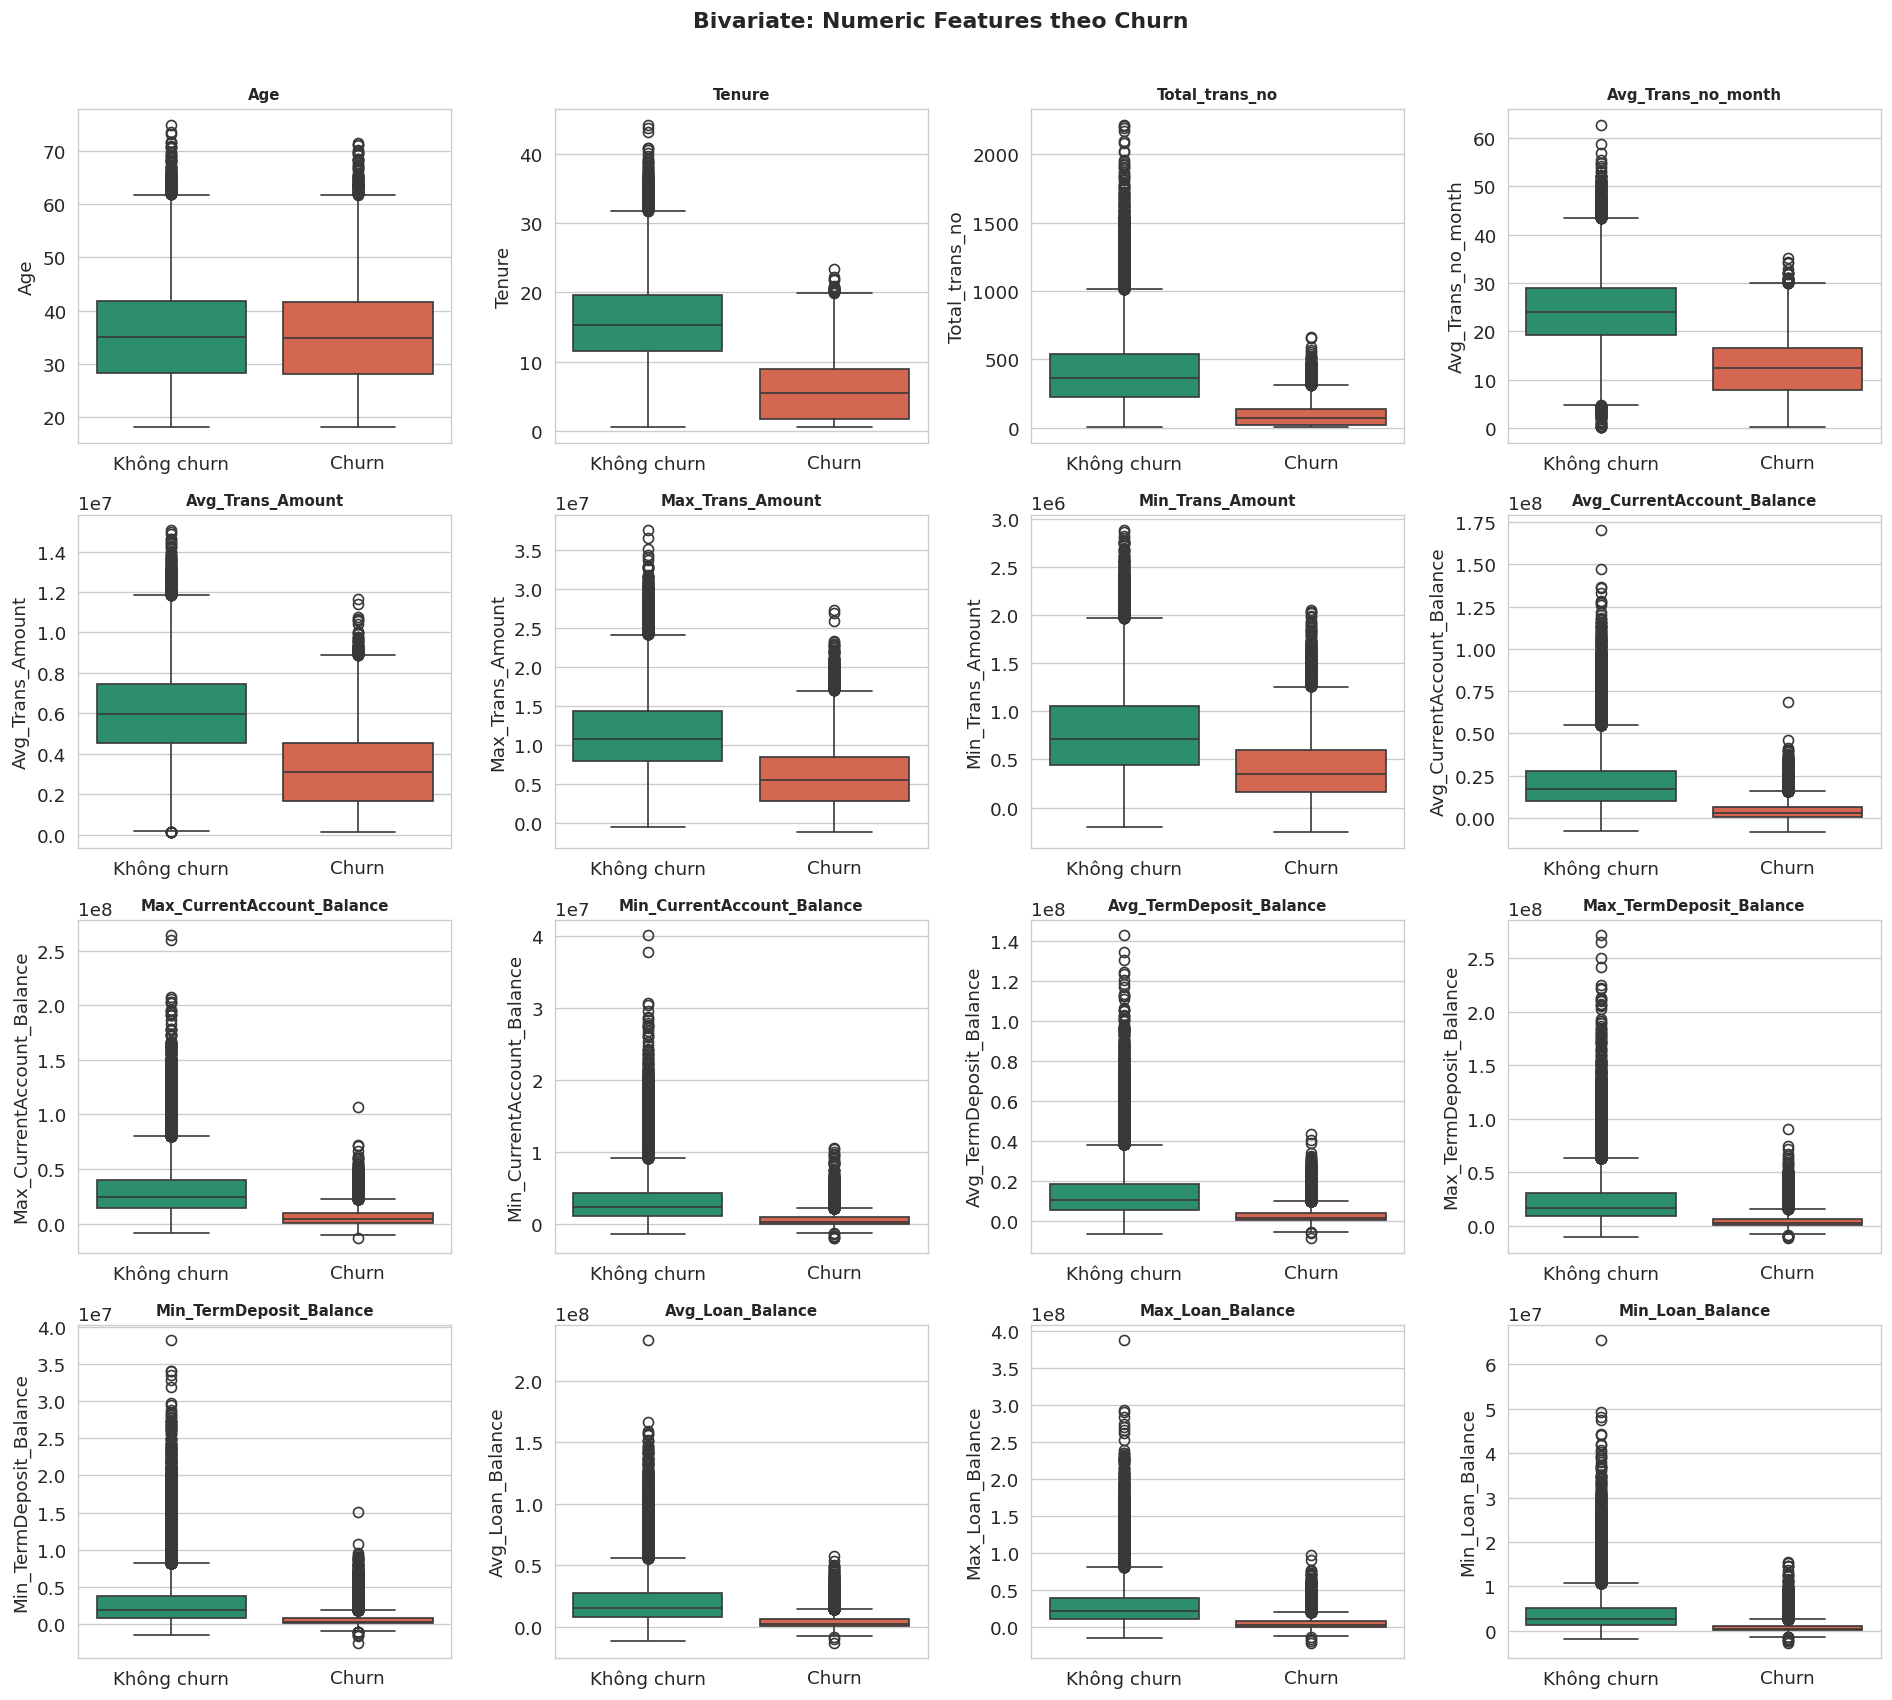

In [9]:
# ============================================================
# PHASE 2 — BIVARIATE: FEATURE vs CHURN
# ============================================================
def plot_bivariate_numeric(df, cols, ncols=4):
    n = len(cols); nrows = int(np.ceil(n/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3.5))
    axes = axes.flatten()
    for ax, col in zip(axes, cols):
        sns.boxplot(data=df, x='Churn', y=col, ax=ax,
                    palette=[COLORS['no_churn'], COLORS['churn']])
        ax.set_xticklabels(['Không churn','Churn']); ax.set_title(col, fontsize=9, fontweight='bold'); ax.set_xlabel('')
    for ax in axes[n:]: ax.axis('off')
    plt.suptitle('Bivariate: Numeric Features theo Churn', fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('eda_bivariate_numeric.png', bbox_inches='tight'); plt.show()

plot_bivariate_numeric(df_raw, continuous_cols)

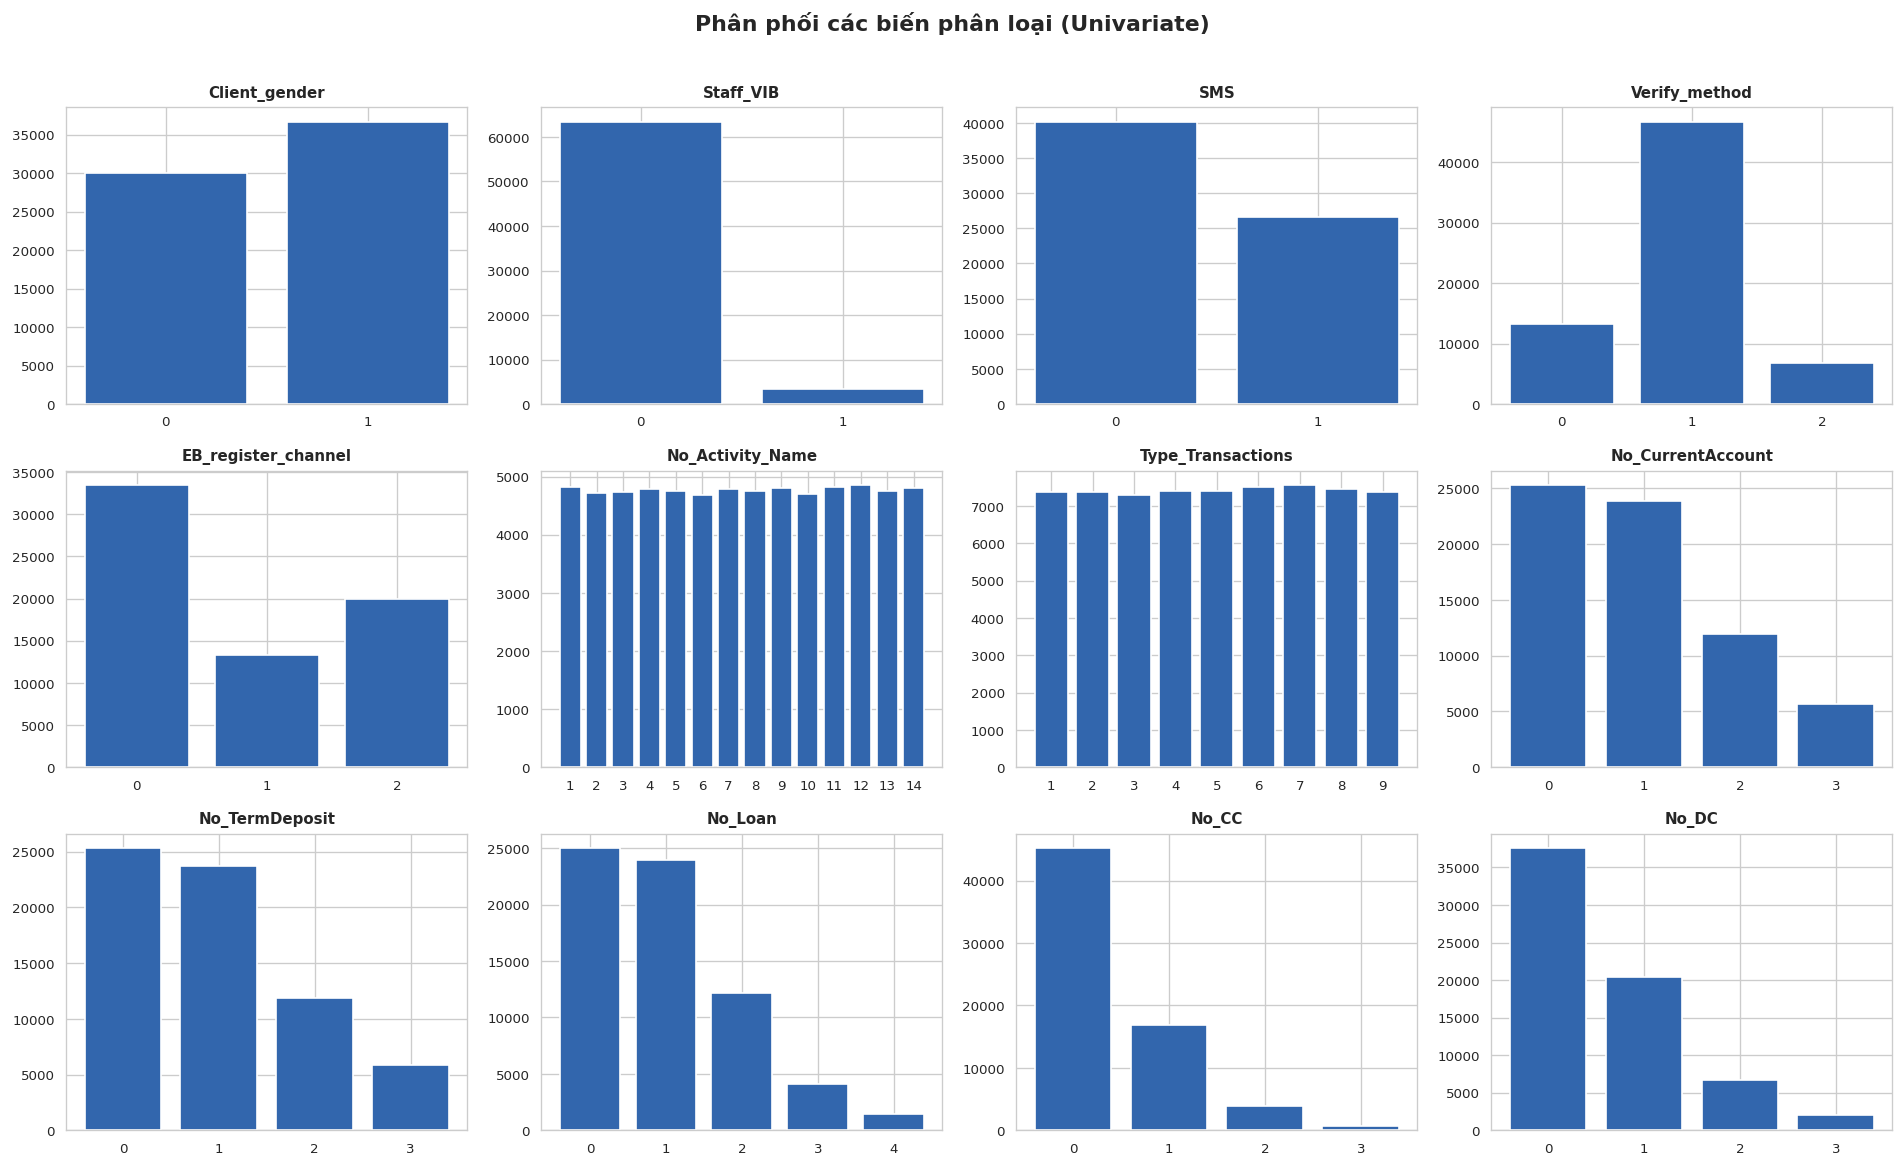

In [10]:
def plot_univariate_categorical(df, cols, ncols=4):
    n = len(cols); nrows = int(np.ceil(n/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3.2))
    axes = axes.flatten()
    for ax, col in zip(axes, cols):
        vc = df[col].value_counts().sort_index()
        ax.bar(vc.index.astype(str), vc.values, color=COLORS['accent'], edgecolor='white')
        ax.set_title(col, fontsize=9, fontweight='bold'); ax.tick_params(labelsize=8)
    for ax in axes[n:]: ax.axis('off')
    plt.suptitle('Phân phối các biến phân loại (Univariate)', fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('eda_univariate_categorical.png', bbox_inches='tight'); plt.show()

plot_univariate_categorical(df_raw, categorical_cols)

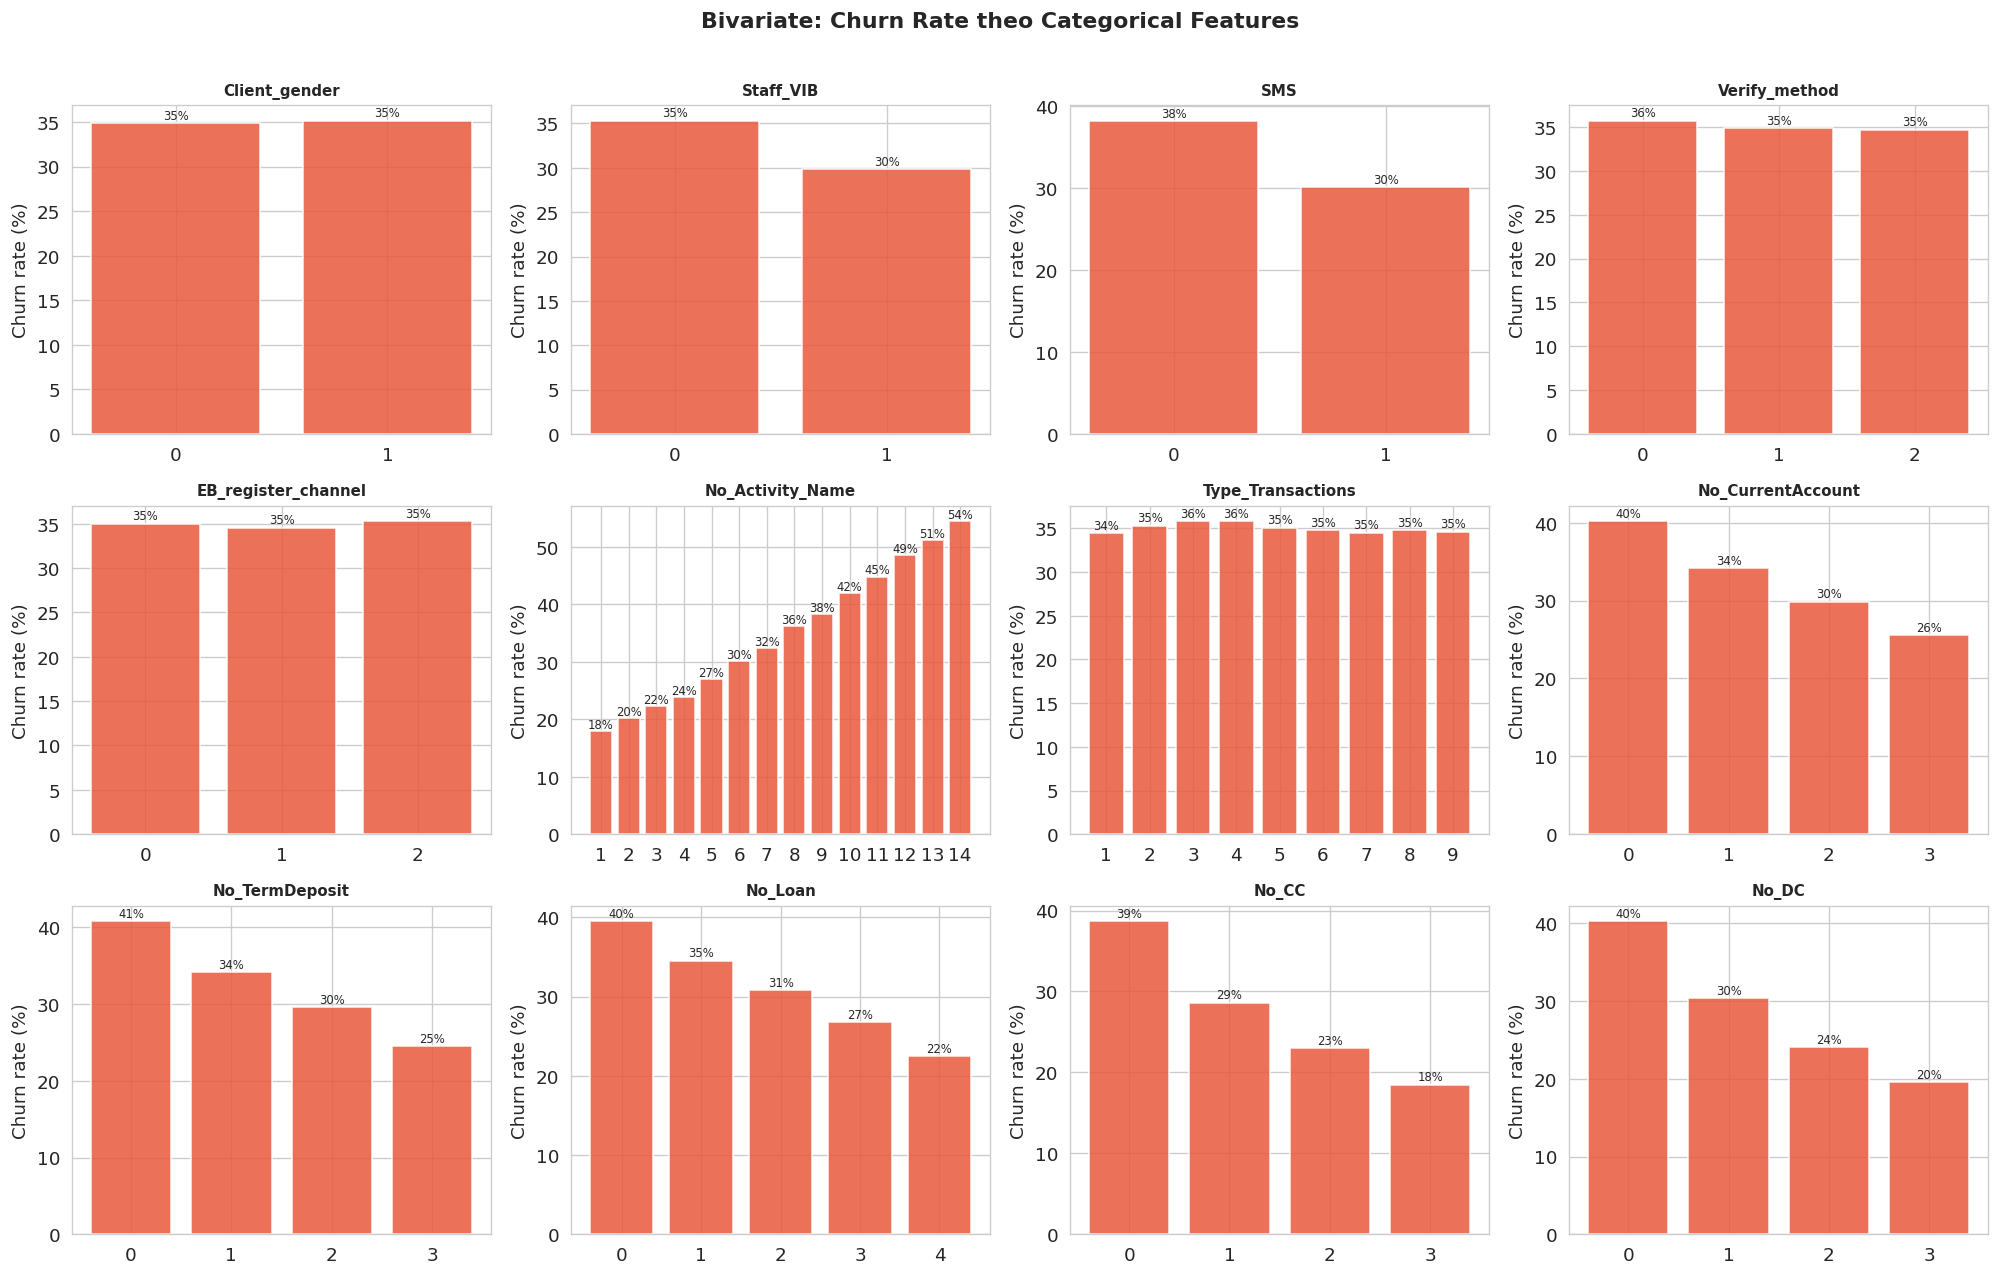

In [11]:
def plot_bivariate_categorical_full(df, cols, ncols=4):
    n = len(cols); nrows = int(np.ceil(n/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.2, nrows*3.5))
    axes = axes.flatten()
    for ax, col in zip(axes, cols):
        churn_rate = df.groupby(col)['Churn'].mean().mul(100).sort_index()
        bars = ax.bar(churn_rate.index.astype(str), churn_rate.values,
                       color=COLORS['churn'], alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, churn_rate.values):
            ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.0f}%', ha='center', fontsize=7)
        ax.set_title(col, fontsize=9, fontweight='bold'); ax.set_ylabel('Churn rate (%)')
    for ax in axes[n:]: ax.axis('off')
    plt.suptitle('Bivariate: Churn Rate theo Categorical Features', fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('eda_bivariate_categorical.png', bbox_inches='tight'); plt.show()

plot_bivariate_categorical_full(df_raw, categorical_cols)

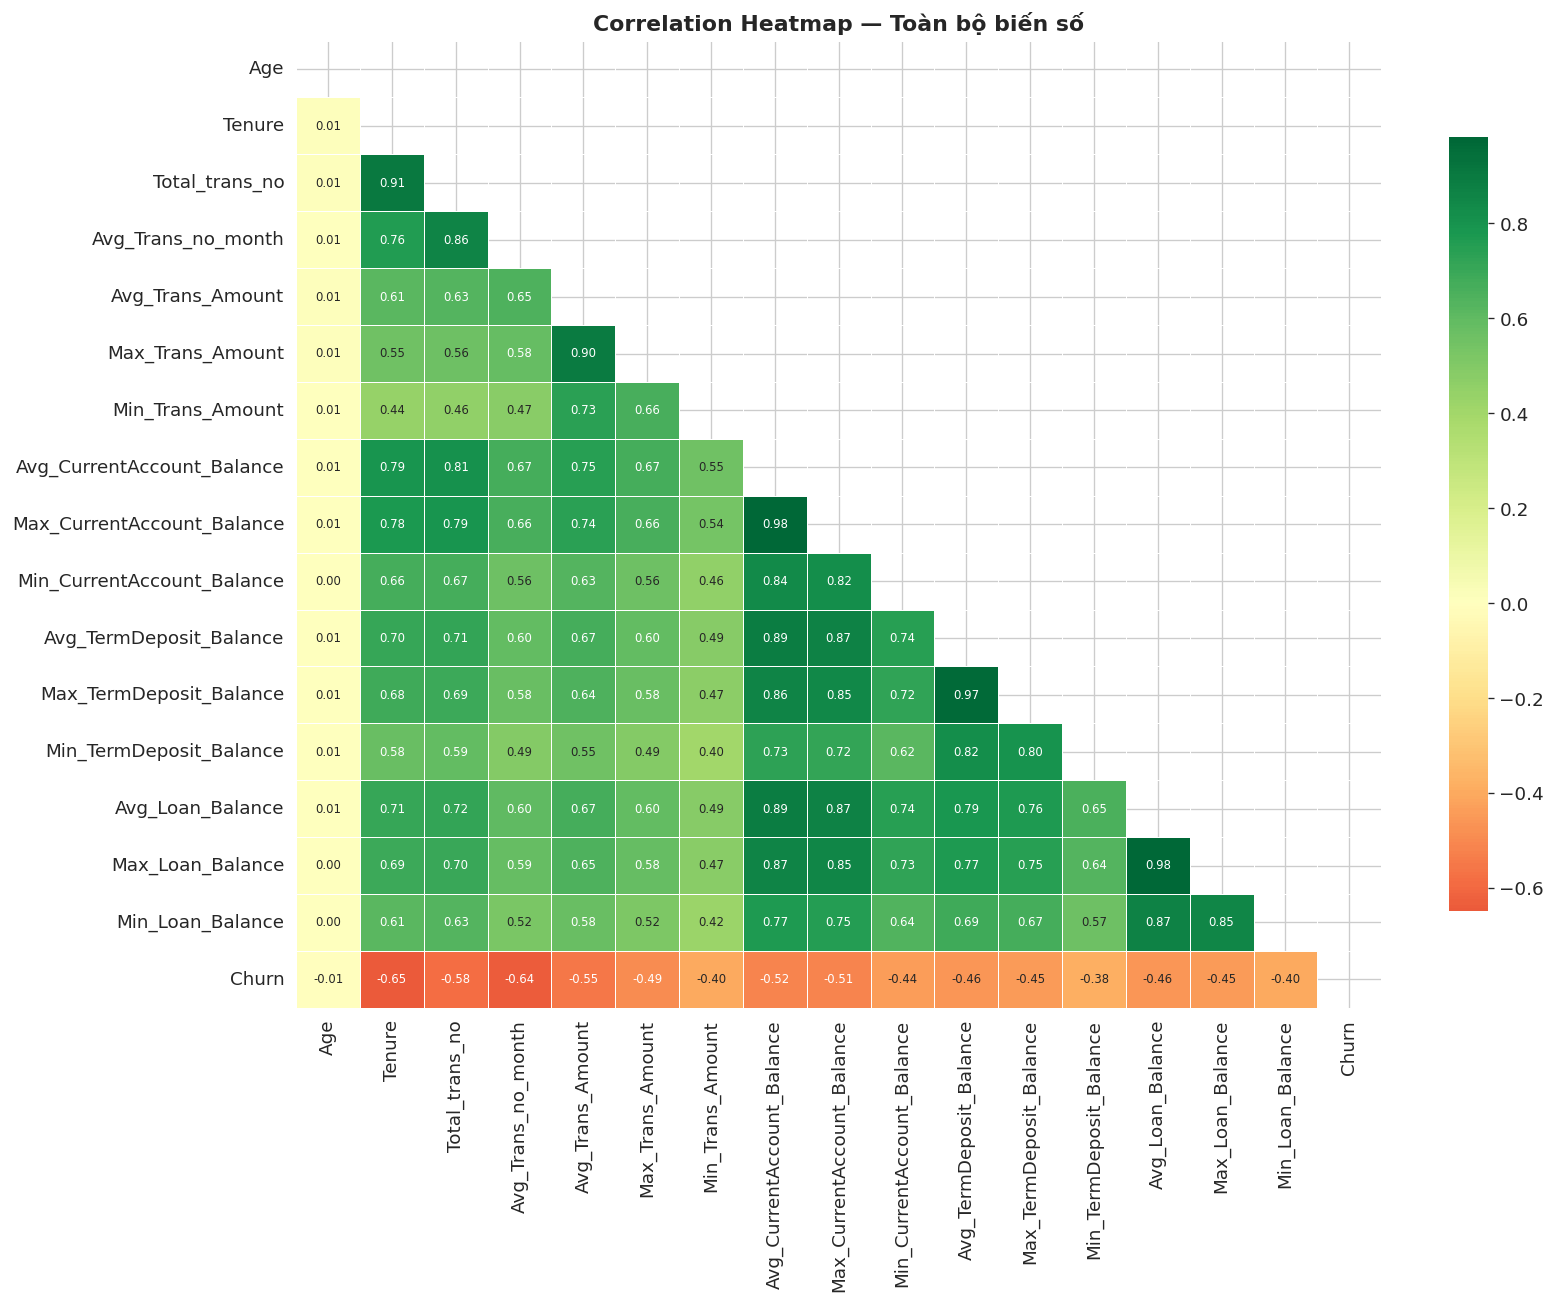

In [12]:
# ============================================================
# PHASE 3 — MULTIVARIATE
# ============================================================
def plot_full_correlation_heatmap(df, cols):
    num_df = df[cols + ['Churn']]
    fig, ax = plt.subplots(figsize=(14, 11))
    mask = np.triu(np.ones_like(num_df.corr(), dtype=bool))
    sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0, mask=mask,
                ax=ax, linewidths=0.4, annot_kws={'size':7}, cbar_kws={'shrink':0.8})
    ax.set_title('Correlation Heatmap — Toàn bộ biến số', fontweight='bold')
    plt.tight_layout(); plt.savefig('eda_full_correlation.png', bbox_inches='tight'); plt.show()

plot_full_correlation_heatmap(df_raw, continuous_cols)

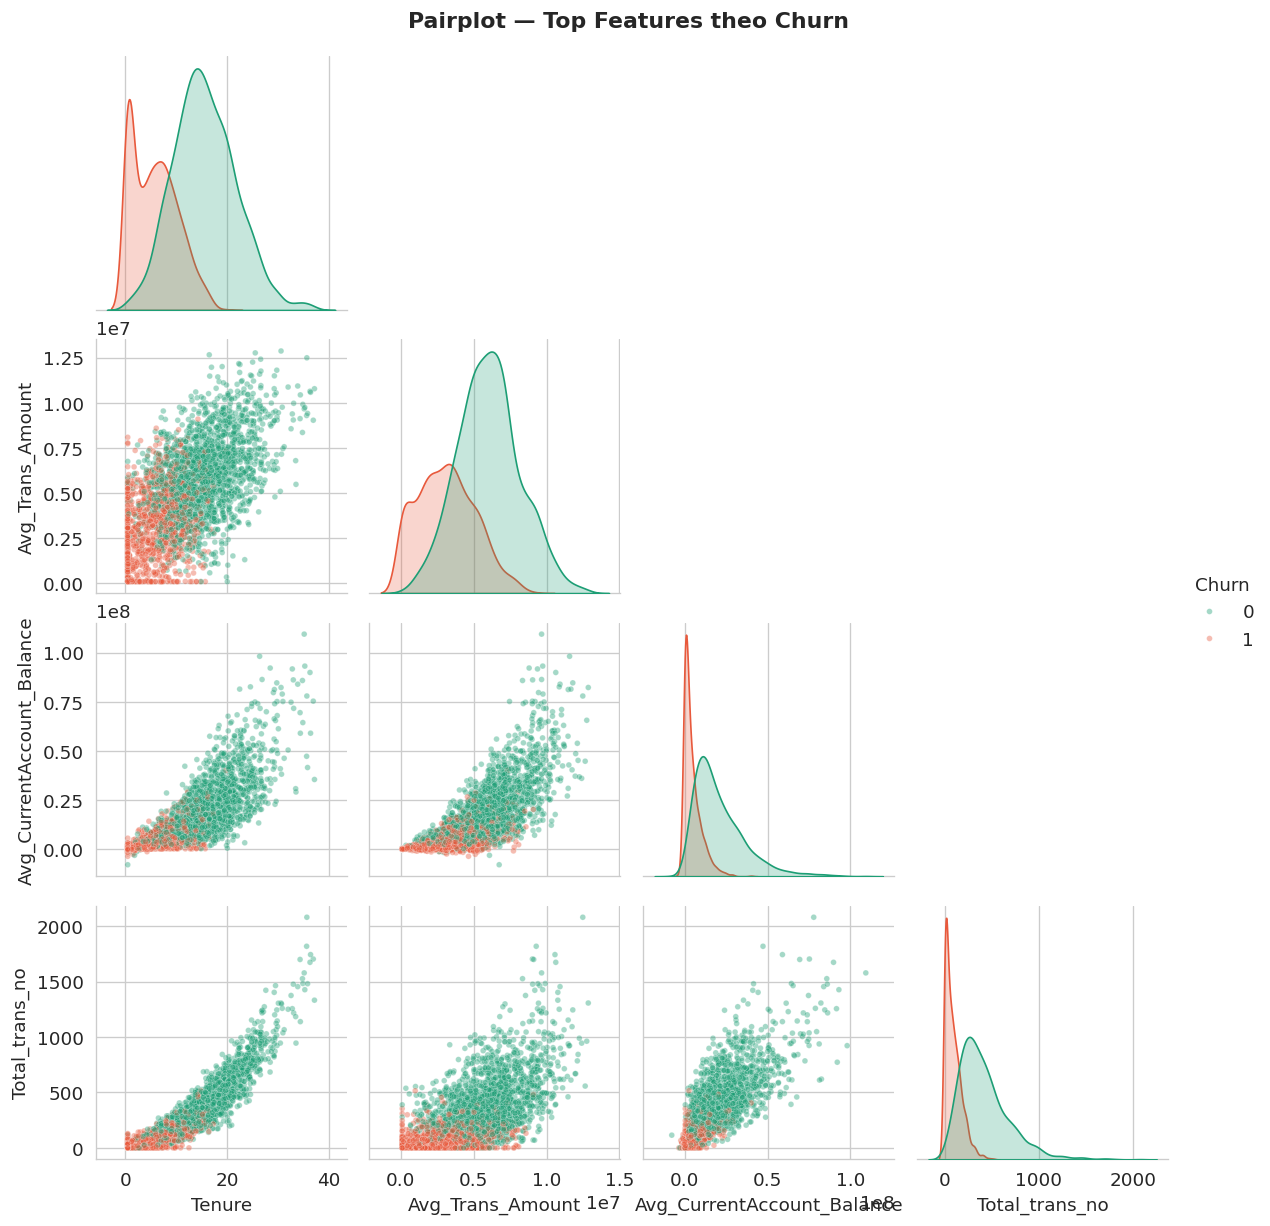

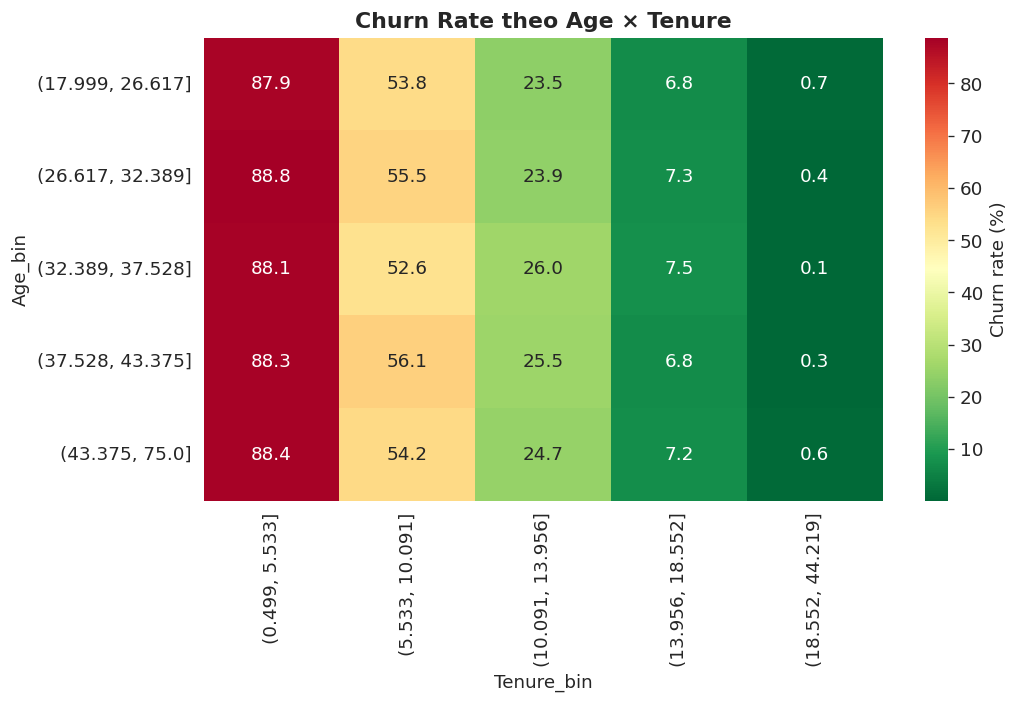

In [13]:
def plot_pairplot_top_features(df, cols, sample_n=3000):
    df_sample = df.sample(min(sample_n, len(df)), random_state=42)
    g = sns.pairplot(df_sample, vars=cols, hue='Churn',
                      palette=[COLORS['no_churn'], COLORS['churn']],
                      plot_kws={'alpha':0.4, 's':12}, diag_kind='kde', corner=True)
    g.fig.suptitle('Pairplot — Top Features theo Churn', fontweight='bold', y=1.02)
    g.savefig('eda_pairplot.png', bbox_inches='tight'); plt.show()

def plot_segment_heatmap(df, row_col='Age', col_col='Tenure', n_bins=5):
    df_tmp = df.copy()
    df_tmp[f'{row_col}_bin'] = pd.qcut(df_tmp[row_col], n_bins, duplicates='drop')
    df_tmp[f'{col_col}_bin'] = pd.qcut(df_tmp[col_col], n_bins, duplicates='drop')
    pivot = df_tmp.pivot_table(values='Churn', index=f'{row_col}_bin',
                                columns=f'{col_col}_bin', aggfunc='mean') * 100
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax, cbar_kws={'label':'Churn rate (%)'})
    ax.set_title(f'Churn Rate theo {row_col} × {col_col}', fontweight='bold')
    plt.tight_layout(); plt.savefig('eda_segment_heatmap.png', bbox_inches='tight'); plt.show()

plot_pairplot_top_features(df_raw, ['Tenure','Avg_Trans_Amount','Avg_CurrentAccount_Balance','Total_trans_no'])
plot_segment_heatmap(df_raw, 'Age', 'Tenure')

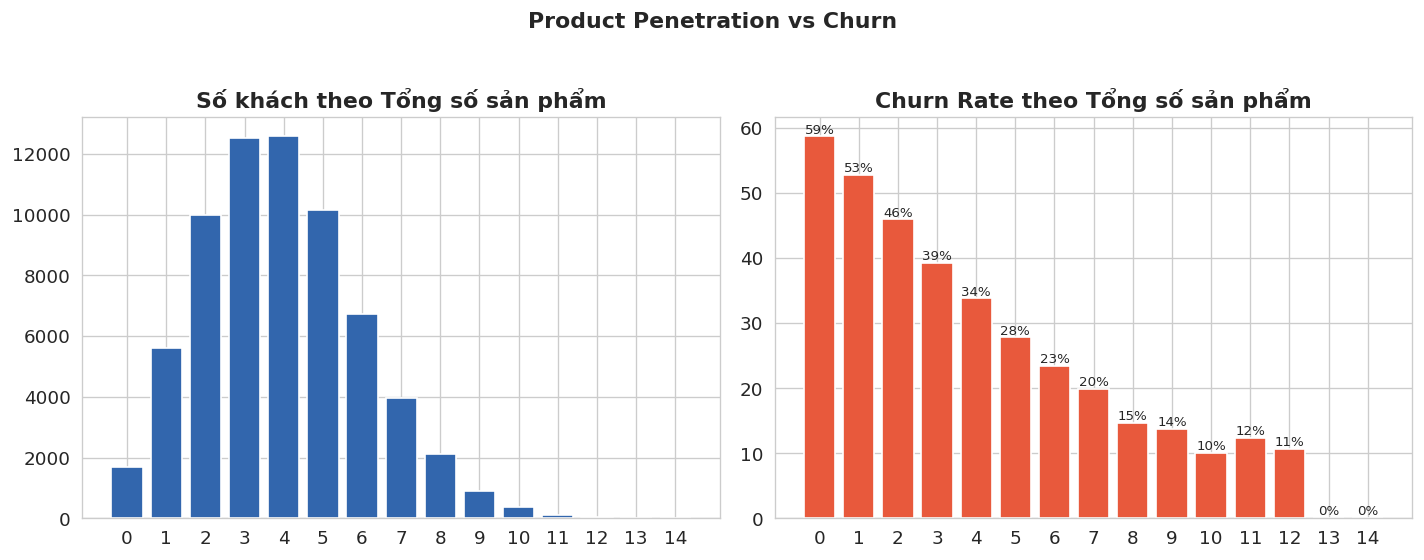

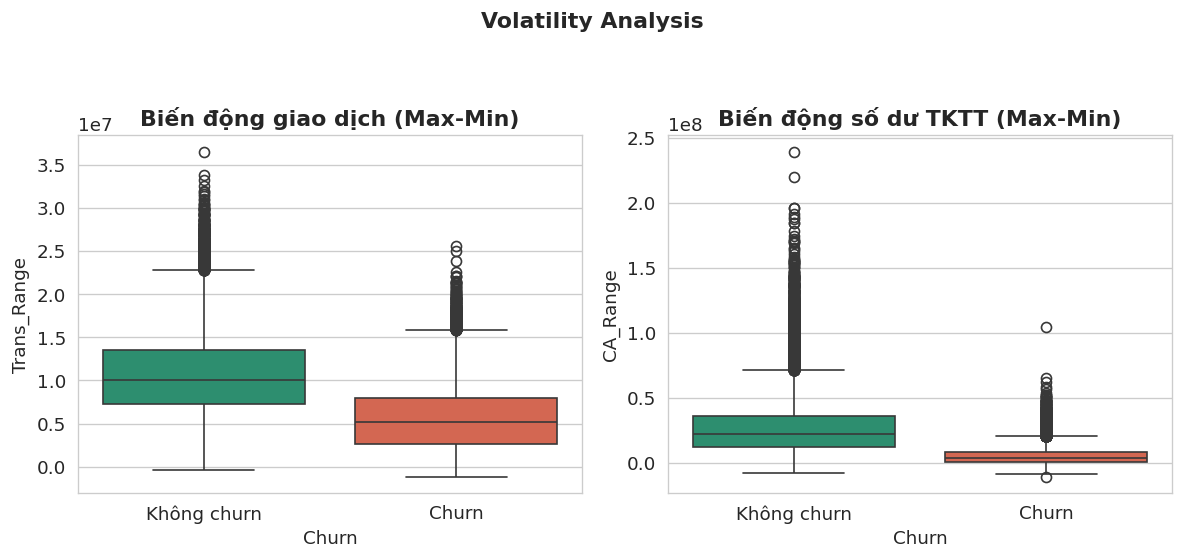

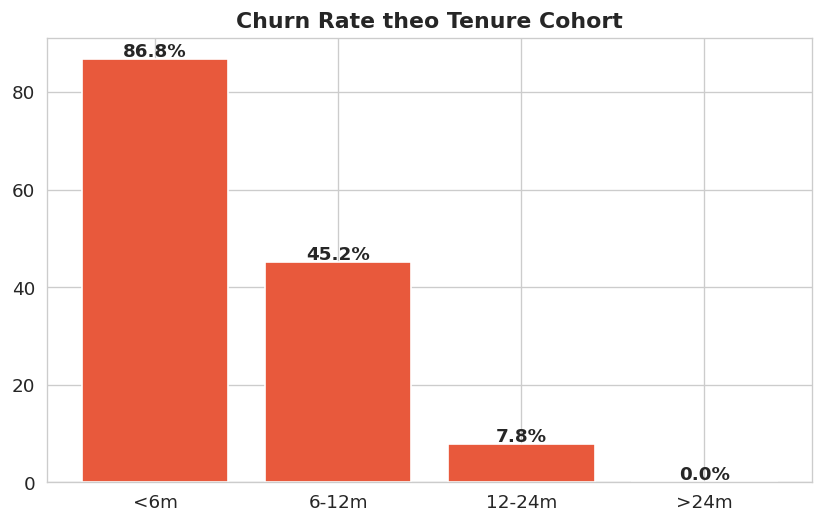

In [14]:
# ============================================================
# PHASE 4 — PHÂN TÍCH ĐẶC THÙ NGÂN HÀNG
# ============================================================
def plot_product_penetration(df):
    df_tmp = df.copy()
    df_tmp['Total_Products'] = (df_tmp['No_CurrentAccount'] + df_tmp['No_TermDeposit'] +
                                  df_tmp['No_Loan'] + df_tmp['No_CC'] + df_tmp['No_DC'])
    churn_rate = df_tmp.groupby('Total_Products')['Churn'].mean().mul(100)
    counts = df_tmp['Total_Products'].value_counts().sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].bar(counts.index.astype(str), counts.values, color=COLORS['accent'], edgecolor='white')
    axes[0].set_title('Số khách theo Tổng số sản phẩm', fontweight='bold')

    bars = axes[1].bar(churn_rate.index.astype(str), churn_rate.values, color=COLORS['churn'], edgecolor='white')
    for bar, val in zip(bars, churn_rate.values):
        axes[1].text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.0f}%', ha='center', fontsize=8)
    axes[1].set_title('Churn Rate theo Tổng số sản phẩm', fontweight='bold')
    plt.suptitle('Product Penetration vs Churn', fontweight='bold', y=1.03)
    plt.tight_layout(); plt.savefig('eda_product_penetration.png', bbox_inches='tight'); plt.show()
    return df_tmp

def plot_balance_volatility(df):
    df_tmp = df.copy()
    df_tmp['Trans_Range'] = df_tmp['Max_Trans_Amount'] - df_tmp['Min_Trans_Amount']
    df_tmp['CA_Range'] = df_tmp['Max_CurrentAccount_Balance'] - df_tmp['Min_CurrentAccount_Balance']

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    sns.boxplot(data=df_tmp, x='Churn', y='Trans_Range', ax=axes[0], palette=[COLORS['no_churn'], COLORS['churn']])
    axes[0].set_xticklabels(['Không churn','Churn']); axes[0].set_title('Biến động giao dịch (Max-Min)', fontweight='bold')
    sns.boxplot(data=df_tmp, x='Churn', y='CA_Range', ax=axes[1], palette=[COLORS['no_churn'], COLORS['churn']])
    axes[1].set_xticklabels(['Không churn','Churn']); axes[1].set_title('Biến động số dư TKTT (Max-Min)', fontweight='bold')
    plt.suptitle('Volatility Analysis', fontweight='bold', y=1.03)
    plt.tight_layout(); plt.savefig('eda_volatility.png', bbox_inches='tight'); plt.show()

def plot_tenure_cohort(df):
    df_tmp = df.copy()
    bins = [0, 6, 12, 24, df['Tenure'].max()]
    labels = ['<6m','6-12m','12-24m','>24m']
    df_tmp['Tenure_Cohort'] = pd.cut(df_tmp['Tenure'], bins=bins, labels=labels)
    churn_rate = df_tmp.groupby('Tenure_Cohort')['Churn'].mean().mul(100)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(churn_rate.index.astype(str), churn_rate.values, color=COLORS['churn'], edgecolor='white')
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.1f}%', ha='center', fontweight='bold')
    ax.set_title('Churn Rate theo Tenure Cohort', fontweight='bold')
    plt.tight_layout(); plt.savefig('eda_tenure_cohort.png', bbox_inches='tight'); plt.show()

df_with_products = plot_product_penetration(df_raw)
plot_balance_volatility(df_raw)
plot_tenure_cohort(df_raw)

In [15]:
# ============================================================
# PHASE 5 — STATISTICAL SIGNIFICANCE
# ============================================================
from scipy.stats import mannwhitneyu, chi2_contingency

def test_numeric_significance(df, cols):
    results = []
    for col in cols:
        stat, p = mannwhitneyu(df[df['Churn']==1][col], df[df['Churn']==0][col], alternative='two-sided')
        results.append({'Feature': col, 'p_value': p, 'Significant': p < 0.05})
    return pd.DataFrame(results).sort_values('p_value')

def test_categorical_significance(df, cols):
    results = []
    for col in cols:
        chi2, p, dof, _ = chi2_contingency(pd.crosstab(df[col], df['Churn']))
        results.append({'Feature': col, 'p_value': p, 'Significant': p < 0.05})
    return pd.DataFrame(results).sort_values('p_value')

num_sig = test_numeric_significance(df_raw, continuous_cols)
cat_sig = test_categorical_significance(df_raw, categorical_cols)
print("📊 Numeric — Mann-Whitney U test:"); display(num_sig)
print("\n📊 Categorical — Chi-square test:"); display(cat_sig)

📊 Numeric — Mann-Whitney U test:


,Feature,p_value,Significant
1,Tenure,0.000000,True
2,Total_trans_no,0.000000,True
3,Avg_Trans_no_month,0.000000,True
4,Avg_Trans_Amount,0.000000,True
6,Min_Trans_Amount,0.000000,True
5,Max_Trans_Amount,0.000000,True
7,Avg_CurrentAccount_Balance,0.000000,True
8,Max_CurrentAccount_Balance,0.000000,True
12,Min_TermDeposit_Balance,0.000000,True
9,Min_CurrentAccount_Balance,0.000000,True



📊 Categorical — Chi-square test:


,Feature,p_value,Significant
5,No_Activity_Name,0.000000e+00,True
11,No_DC,1.948785e-262,True
10,No_CC,6.855453e-195,True
8,No_TermDeposit,1.226750e-174,True
7,No_CurrentAccount,3.222086e-143,True
9,No_Loan,1.626751e-115,True
2,SMS,4.191759e-102,True
1,Staff_VIB,2.479450e-10,True
3,Verify_method,1.727285e-01,False
4,EB_register_channel,3.937981e-01,False


## 🔧 Pha 3 — Tiền xử lý & Feature Engineering

In [16]:
# ============================================================
# TIỀN XỬ LÝ — dùng df_raw từ bước load
# ============================================================

df = df_raw.copy()

# 1. Tách X, y
X = df.drop(columns=['Churn'])
y = df['Churn']
feature_names = list(X.columns)

# 2. Chia train/test (CHƯA scale, CHƯA SMOTE)
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print('--- y_train TRƯỚC SMOTE ---')
print(y_train_raw.value_counts())

# 3. Scale: fit CHỈ trên train gốc
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 4. SMOTE CHỈ trên train
smote = SMOTE(random_state=SEED)
X_train_smote, y_train = smote.fit_resample(X_train_scaled, y_train_raw)

print('\n--- y_train SAU SMOTE ---')
print(pd.Series(y_train).value_counts())

# 5. DataFrame (cho SHAP / hiển thị)
X_train = pd.DataFrame(X_train_smote, columns=feature_names)
X_test  = pd.DataFrame(X_test_scaled, columns=feature_names)

# 6. Giữ bản raw test cho giải thích SHAP (giá trị gốc, dễ đọc)
X_test_for_shap = X_test_raw.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print('\n--- TIỀN XỬ LÝ HOÀN TẤT ---')
print(f'Train (đã SMOTE): {X_train.shape[0]:,} × {X_train.shape[1]}')
print(f'Test  (gốc)     : {X_test.shape[0]:,} × {X_test.shape[1]}')

--- y_train TRƯỚC SMOTE ---
Churn
0    34702
1    18686
Name: count, dtype: int64

--- y_train SAU SMOTE ---
Churn
1    34702
0    34702
Name: count, dtype: int64

--- TIỀN XỬ LÝ HOÀN TẤT ---
Train (đã SMOTE): 69,404 × 28
Test  (gốc)     : 13,348 × 28


## 🤖 Pha 4 — Huấn luyện 5 Mô Hình Đơn Lẻ

In [17]:
# Định nghĩa 5 models
MODELS = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42, n_jobs=-1
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=10, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=7, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1
    ),
    'SVM': SVC(
        C=1.0, kernel='rbf', probability=True, random_state=42
    ),
}

def make_model_pipeline(model, use_scaler=True):
  """Pipeline chuẩn: Scaler (tuỳ chọn) + SMOTE + Model — dùng cho CV."""
  steps = []
  if use_scaler:
    steps.append(('scaler', StandardScaler()))
  steps.append(('smote', SMOTE(random_state=SEED)))
  steps.append(('clf', model))
  return ImbPipeline(steps)

def train_all_models(models, X_train, y_train):
    """Huấn luyện tất cả models, trả về dict trained models."""
    trained = {}
    for name, model in models.items():
        print(f'  Đang train: {name}...', end=' ')
        model.fit(X_train, y_train)
        trained[name] = model
        print('✅')
    return trained

print('🚀 Bắt đầu training...')
trained_models = train_all_models(MODELS, X_train, y_train)
print('\n✅ Training hoàn tất!')

🚀 Bắt đầu training...
  Đang train: Logistic Regression... ✅
  Đang train: Decision Tree... ✅
  Đang train: Random Forest... ✅
  Đang train: XGBoost... ✅
  Đang train: SVM... ✅

✅ Training hoàn tất!


## 📈 Pha 5 — Đánh Giá & So Sánh Models

📊 Bảng so sánh models (sắp xếp theo AUC-ROC):


,Threshold,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,,
XGBoost,0.5000,0.9117,0.8581,0.8958,0.8765,0.9747
Logistic Regression,0.5000,0.9104,0.8455,0.9103,0.8767,0.9745
SVM,0.5000,0.9095,0.8503,0.8998,0.8744,0.9725
Random Forest,0.5000,0.8946,0.8157,0.9028,0.8571,0.9640
Decision Tree,0.5000,0.8948,0.8169,0.9015,0.8571,0.9586


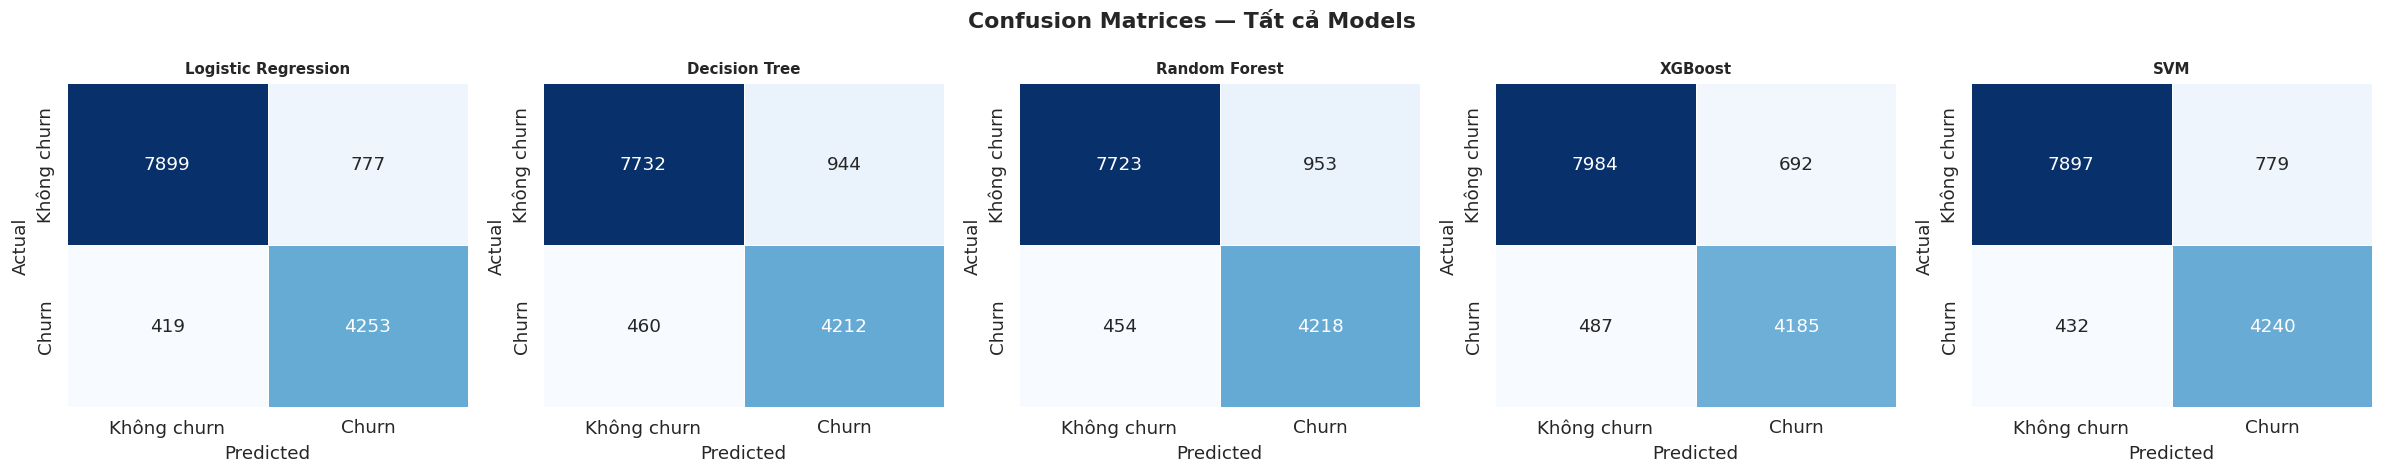

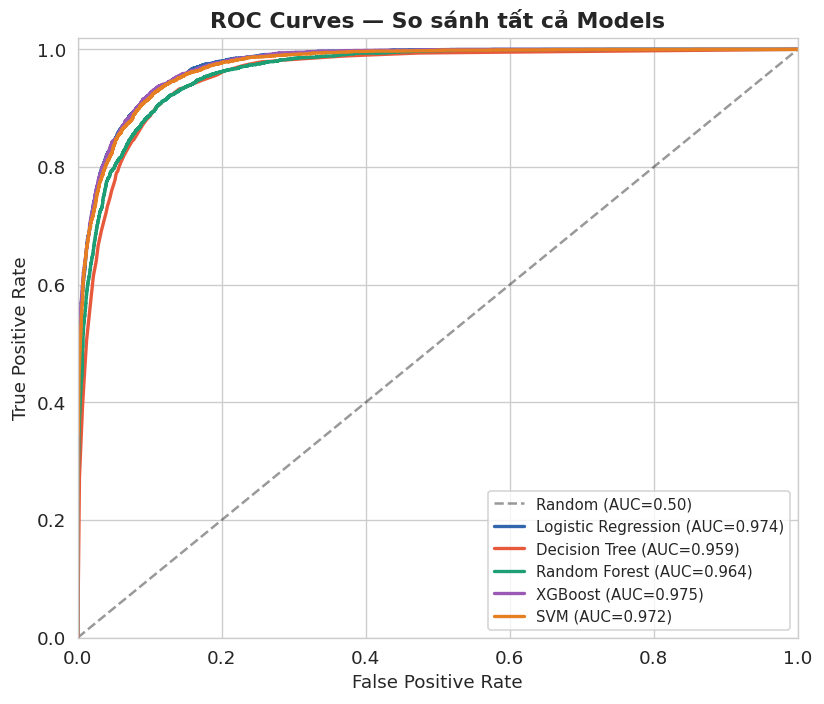

In [23]:
def find_best_threshold(model, X_test, y_test, min_recall=0.90):
  """Tìm ngưỡng để recall churn >= min_recall."""
  y_proba = model.predict_proba(X_test)[:, 1]
  prec, rec, thresholds = precision_recall_curve(y_test, y_proba)

  valid_idx = np.where(rec[:-1] >= min_recall)[0]
  if len(valid_idx) == 0:
    return 0.5

  best_idx = valid_idx[-1]
  return thresholds[best_idx]

def evaluate_model(model, X_test, y_test, model_name='Model', threshold=0.5):
  if hasattr(model, 'predict_proba'):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
  else:
    # Hard Voting không có predict_proba -> dùng predict() trực tiếp
    y_pred = model.predict(X_test)
    y_proba = y_pred  # dùng nhãn 0/1 thay cho xác suất khi tính AUC

  metrics = {
    'Model'     : model_name,
    'Threshold' : round(threshold, 4) if hasattr(model, 'predict_proba') else None,
    'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
    'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
    'Recall'    : round(recall_score(y_test, y_pred, zero_division=0), 4),
    'F1'        : round(f1_score(y_test, y_pred, zero_division=0), 4),
    'AUC-ROC'   : round(roc_auc_score(y_test, y_proba), 4),
  }
  return metrics

def compare_models_table(trained_models, X_test, y_test):
    """Bảng so sánh tất cả models."""
    results = [evaluate_model(m, X_test, y_test, name)
               for name, m in trained_models.items()]
    df_res = pd.DataFrame(results).set_index('Model')
    df_res = df_res.sort_values('AUC-ROC', ascending=False)

    # Highlight giá trị tốt nhất
    styled = (df_res.style
               .highlight_max(axis=0, color='#c8f7c5')
               .format('{:.4f}'))
    return df_res, styled

def plot_confusion_matrices(trained_models, X_test, y_test):
    """Vẽ confusion matrix cho tất cả models."""
    n = len(trained_models)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    for ax, (name, model) in zip(axes, trained_models.items()):
        cm = confusion_matrix(y_test, model.predict(X_test))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    linewidths=0.5, cbar=False,
                    xticklabels=['Không churn', 'Churn'],
                    yticklabels=['Không churn', 'Churn'])
        ax.set_title(name, fontweight='bold', fontsize=9)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    plt.suptitle('Confusion Matrices — Tất cả Models', fontweight='bold')
    plt.tight_layout()
    plt.savefig('confusion_matrices.png', bbox_inches='tight')
    plt.show()

def plot_roc_curves(trained_models, X_test, y_test):
    """ROC curves tất cả models trên 1 biểu đồ."""
    palette = ['#3266ad', '#E8593C', '#1D9E75', '#9b59b6', '#e67e22']
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random (AUC=0.50)')

    for (name, model), color in zip(trained_models.items(), palette):
        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            auc = roc_auc_score(y_test, y_prob)
            ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves — So sánh tất cả Models', fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    plt.tight_layout()
    plt.savefig('roc_curves.png', bbox_inches='tight')
    plt.show()

results_df, styled_table = compare_models_table(trained_models, X_test, y_test)
print('📊 Bảng so sánh models (sắp xếp theo AUC-ROC):')
display(styled_table)

plot_confusion_matrices(trained_models, X_test, y_test)
plot_roc_curves(trained_models, X_test, y_test)

In [24]:
def cross_validate_all(models_dict, X_train_raw, y_train_raw, cv=5):
  """
  CV đúng chuẩn: SMOTE chỉ áp dụng trong từng fold train.
  Dùng dữ liệu GỐC (chưa SMOTE).
  """
  skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
  cv_results = {}

  print(f'Cross-validation {cv}-fold (SMOTE trong pipeline):')
  for name, model in models_dict.items():
    # Tree model không cần scale
    use_scaler = name in ['Logistic Regression', 'SVM']
    pipe = make_model_pipeline(model, use_scaler=use_scaler)

  scores = cross_val_score(
      pipe, X_train_raw, y_train_raw,
      cv=skf, scoring='roc_auc', n_jobs=-1
  )
  cv_results[name] = scores
  print(f'  {name:25s}: {scores.mean():.4f} ± {scores.std():.4f}')

  return cv_results

# Dùng MODELS (chưa fit), KHÔNG dùng X_train đã SMOTE
cv_results = cross_validate_all(MODELS, X_train_raw, y_train_raw)

Cross-validation 5-fold (SMOTE trong pipeline):
  SVM                      : 0.9732 ± 0.0010


## 🗳️ Pha 6 — Voting Ensemble (Hard & Soft)

In [25]:
def build_voting_classifier(trained_models, voting='soft'):
    """Xây dựng VotingClassifier từ các models đã train."""
    estimators = [(name, model) for name, model in trained_models.items()]
    voter = VotingClassifier(estimators=estimators, voting=voting, n_jobs=-1)
    return voter

def compare_ensemble_vs_single(ensemble_models, single_models, X_test, y_test):
    """Bảng so sánh cuối: ensemble vs models đơn lẻ."""
    all_models = {**single_models, **ensemble_models}
    results = [evaluate_model(m, X_test, y_test, name)
               for name, m in all_models.items()]
    df_cmp = pd.DataFrame(results).set_index('Model')
    df_cmp = df_cmp.sort_values('AUC-ROC', ascending=False)
    return df_cmp

# Build và train 2 loại voting
print('🗳️  Đang build Hard Voting...', end=' ')
hard_voter = build_voting_classifier(trained_models, voting='hard')
hard_voter.fit(X_train, y_train)
print('✅')

print('🗳️  Đang build Soft Voting...', end=' ')
soft_voter = build_voting_classifier(trained_models, voting='soft')
soft_voter.fit(X_train, y_train)
print('✅')

ensemble_models = {
    'Hard Voting': hard_voter,
    'Soft Voting': soft_voter,
}

# Bảng so sánh cuối
final_comparison = compare_ensemble_vs_single(ensemble_models, trained_models, X_test, y_test)
print('\n📊 So sánh TỔNG HỢP — Models đơn lẻ vs Ensemble:')
styled_final = (final_comparison.style
                .highlight_max(axis=0, color='#ffd700')
                .format('{:.4f}'))
display(styled_final)

🗳️  Đang build Hard Voting... ✅
🗳️  Đang build Soft Voting... ✅

📊 So sánh TỔNG HỢP — Models đơn lẻ vs Ensemble:


,Threshold,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,,
XGBoost,0.5000,0.9117,0.8581,0.8958,0.8765,0.9747
Logistic Regression,0.5000,0.9104,0.8455,0.9103,0.8767,0.9745
Soft Voting,0.5000,0.9111,0.8470,0.9103,0.8775,0.9736
SVM,0.5000,0.9095,0.8503,0.8998,0.8744,0.9725
Random Forest,0.5000,0.8946,0.8157,0.9028,0.8571,0.9640
Decision Tree,0.5000,0.8948,0.8169,0.9015,0.8571,0.9586
Hard Voting,nan,0.9126,0.8478,0.9144,0.8798,0.9130


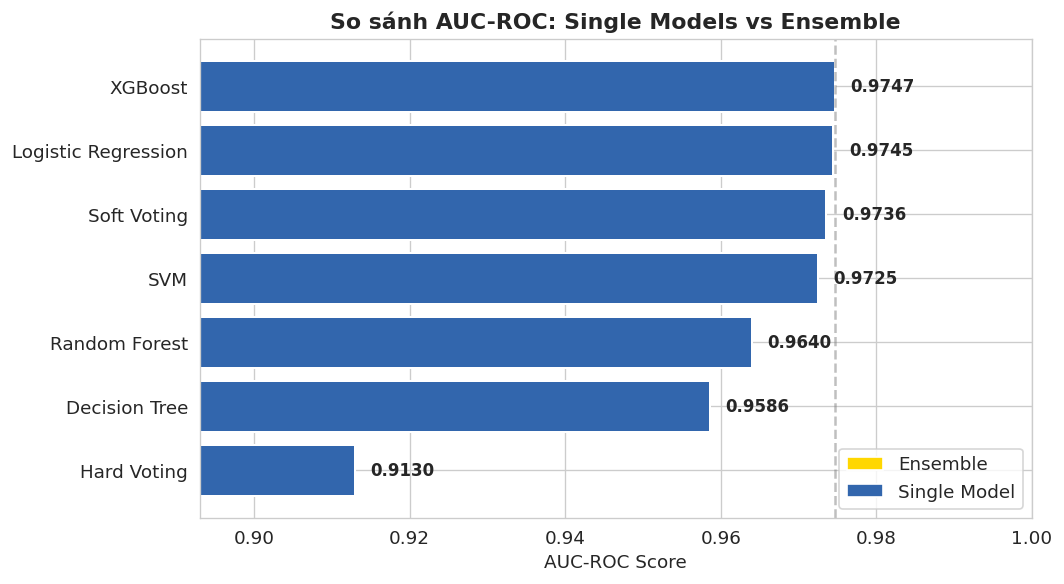

In [26]:
def plot_final_comparison_bar(df_comparison):
    """Bar chart so sánh AUC-ROC của tất cả models."""
    df_plot = df_comparison.sort_values('AUC-ROC')
    colors = ['#ffd700' if '🗳️' in idx else COLORS['accent']
              for idx in df_plot.index]

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(df_plot.index, df_plot['AUC-ROC'],
                   color=colors, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, df_plot['AUC-ROC']):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontweight='bold', fontsize=10)

    ax.set_xlabel('AUC-ROC Score', fontsize=11)
    ax.set_title('So sánh AUC-ROC: Single Models vs Ensemble', fontweight='bold')
    ax.set_xlim(df_plot['AUC-ROC'].min() - 0.02, 1.0)
    ax.axvline(x=df_comparison[~df_comparison.index.str.contains('🗳️')]['AUC-ROC'].max(),
               color='gray', linestyle='--', alpha=0.5, label='Best single model')

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#ffd700', label='Ensemble'),
        Patch(facecolor=COLORS['accent'], label='Single Model')
    ]
    ax.legend(handles=legend_elements)
    plt.tight_layout()
    plt.savefig('final_comparison.png', bbox_inches='tight')
    plt.show()

plot_final_comparison_bar(final_comparison)

## 🔍 Pha 7 — Giải Thích Mô Hình với SHAP

Đang tính SHAP values cho XGBoost...


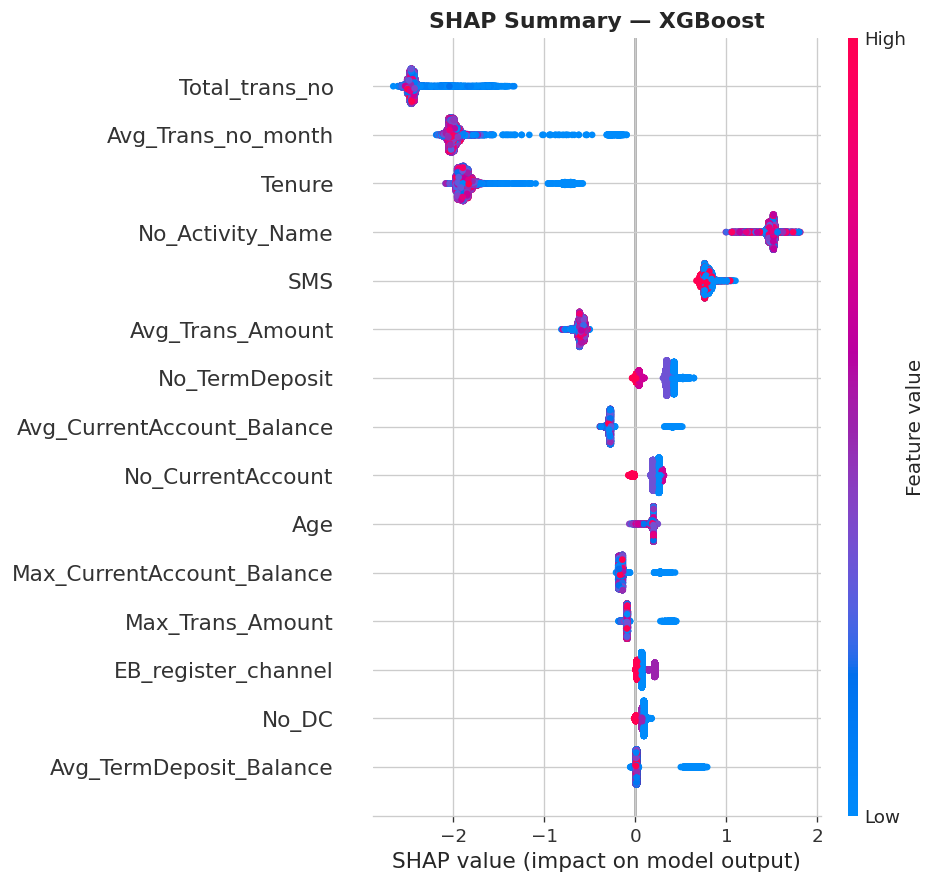

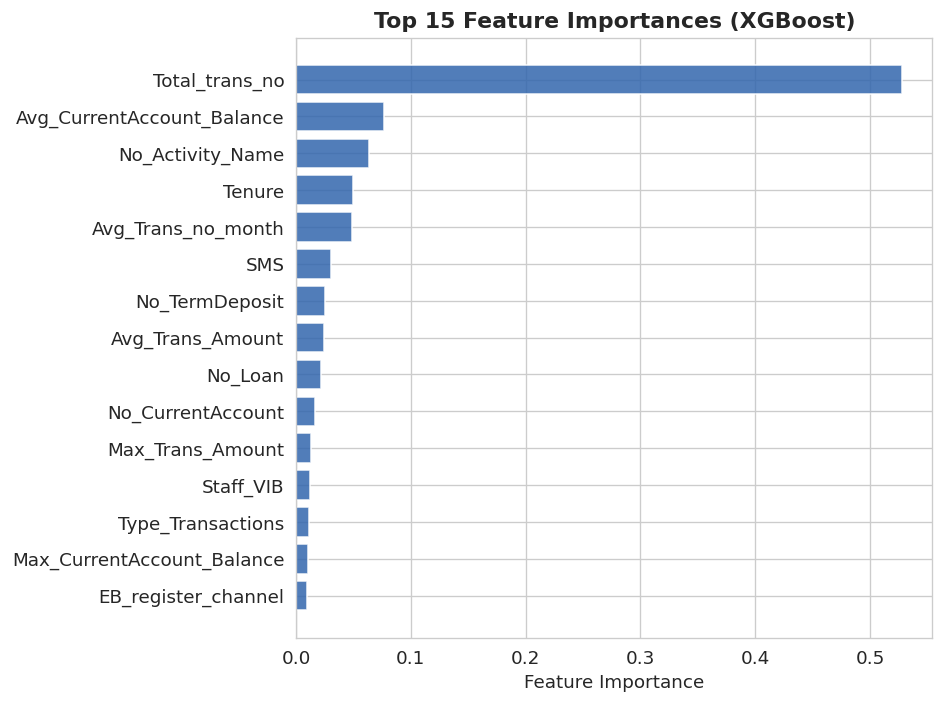

In [27]:
def plot_shap_summary(model, X_test_raw, feature_names, model_name='XGBoost'):
  print(f'Đang tính SHAP values cho {model_name}...')
  X_df = X_test_raw[feature_names].copy()
  explainer = shap.TreeExplainer(model)
  shap_values = explainer.shap_values(X_df)

  plt.figure(figsize=(10, 7))
  shap.summary_plot(shap_values, X_df, show=False, max_display=15)
  plt.title(f'SHAP Summary — {model_name}', fontweight='bold')
  plt.tight_layout()
  plt.savefig('shap_summary.png', bbox_inches='tight')
  plt.show()
  return explainer, shap_values

def plot_feature_importance(model, feature_names, top_n=15):
    """Feature importance từ tree-based model."""
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(range(top_n), importances[indices],
            color=COLORS['accent'], alpha=0.85, edgecolor='white')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] for i in indices])
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top {top_n} Feature Importances (XGBoost)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance.png', bbox_inches='tight')
    plt.show()

def explain_single_prediction(explainer, model, X_sample, feature_names, idx=0):
    """Giải thích dự đoán cho 1 khách hàng cụ thể."""
    X_df = pd.DataFrame(X_sample, columns=feature_names)
    shap_vals = explainer.shap_values(X_df)
    pred_prob = model.predict_proba(X_sample[idx:idx+1])[0][1]

    print(f'\n👤 Khách hàng #{idx}: Xác suất churn = {pred_prob:.1%}')
    print('Prediction:', '⚠️  CHURN' if pred_prob > 0.5 else '✅ KHÔNG CHURN')

    plt.figure(figsize=(10, 4))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals[idx],
            base_values=explainer.expected_value,
            data=X_df.iloc[idx].values,
            feature_names=feature_names
        ), show=False
    )
    plt.title(f'SHAP Waterfall — Khách hàng #{idx} (P(churn)={pred_prob:.1%})',
              fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'shap_waterfall_{idx}.png', bbox_inches='tight')
    plt.show()

# Dùng XGBoost làm model chính để giải thích
xgb_model = trained_models['XGBoost']
explainer, shap_values = plot_shap_summary(
    xgb_model, X_test_for_shap, feature_names, 'XGBoost')
plot_feature_importance(xgb_model, feature_names, top_n=15)


👤 Khách hàng #3: Xác suất churn = 2.1%
Prediction: ✅ KHÔNG CHURN


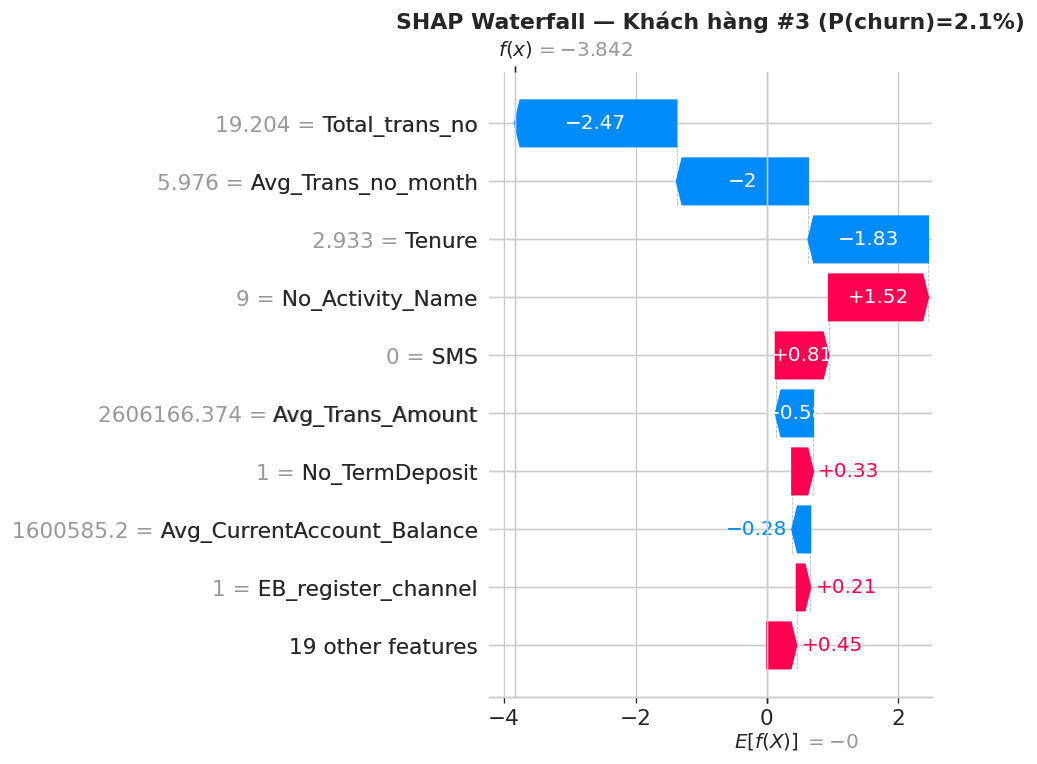


👤 Khách hàng #0: Xác suất churn = 1.9%
Prediction: ✅ KHÔNG CHURN


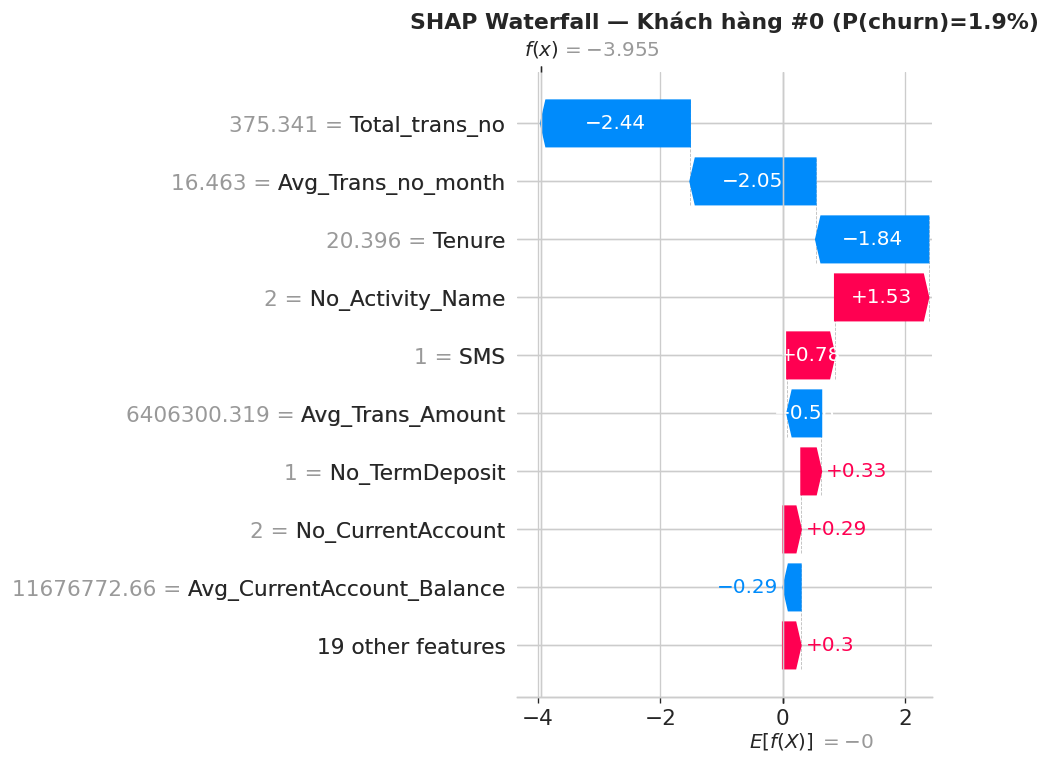

In [28]:
# Giải thích dự đoán cho 2 khách hàng cụ thể
# Tìm 1 khách hàng churn thật và 1 không churn
y_test_arr = np.array(y_test)
churn_idx    = np.where(y_test_arr == 1)[0][0]
no_churn_idx = np.where(y_test_arr == 0)[0][0]

explain_single_prediction(explainer, xgb_model, X_test_for_shap, feature_names, idx=churn_idx)
explain_single_prediction(explainer, xgb_model, X_test_for_shap, feature_names, idx=no_churn_idx)

## 💾 Pha 8 — Lưu Model & Dự Đoán Khách Hàng Mới

In [29]:
def save_model(model, scaler, feature_names, threshold, model_name, path='best_churn_model.pkl'):
  artifact = {
    'model': model,
    'scaler': scaler,
    'feature_names': list(feature_names),
    'threshold': threshold,
    'model_name': model_name,
    'seed': SEED,
  }
  joblib.dump(artifact, path)
  print(f'Đã lưu model: {path}')

def load_model(path='best_churn_model.pkl'):
  artifact = joblib.load(path)
  return artifact

# Chọn model tốt nhất
best_model_name = final_comparison.index[0]
print(f'Model tốt nhất: {best_model_name}')

all_models_combined = {**trained_models, **ensemble_models}
best_model = all_models_combined[best_model_name]

# Dùng threshold đã tune (hoặc 0.5 nếu chưa tune)
save_model(
    best_model, scaler, feature_names,
    threshold=best_threshold if 'best_threshold' in dir() else 0.5,
    model_name=best_model_name,
    path='best_churn_model.pkl'
)

Model tốt nhất: XGBoost
Đã lưu model: best_churn_model.pkl


In [30]:
def predict_new_customer(artifact, customer_dict):
  """
  customer_dict: dict đủ key trùng feature_names, giá trị số như trong dataset.
  """
  feature_names = artifact['feature_names']
  model = artifact['model']
  scaler = artifact['scaler']
  threshold = artifact.get('threshold', 0.5)

  # Kiểm tra thiếu cột
  missing = set(feature_names) - set(customer_dict.keys())
  if missing:
    raise ValueError(f'Thiếu features: {missing}')

  X_new = pd.DataFrame([customer_dict])[feature_names]
  X_new_sc = scaler.transform(X_new)
  prob = model.predict_proba(X_new_sc)[0, 1]
  pred = 'CHURN' if prob >= threshold else 'KHÔNG CHURN'

  print('=' * 45)
  print(f'  Kết quả: {pred}')
  print(f'  Xác suất churn: {prob:.1%}')
  print(f'  Ngưỡng dùng: {threshold:.4f}')
  print('=' * 45)
  return prob

# Load artifact vừa lưu
artifact = load_model('best_churn_model.pkl')

new_customer = {
    'Client_gender': 1.0,
    'Age': 40.0,
    'Staff_VIB': 0.0,
    'Tenure': 7.0,
    'SMS': 0.0,
    'Verify_method': 0.0,
    'EB_register_channel': 0.0,
    'No_Activity_Name': 11.0,
    'Type_Transactions': 3.0,
    'Total_trans_no': 20.0,
    'Avg_Trans_no_month': 1.5,
    'Avg_Trans_Amount': 5_000_000.0,
    'Max_Trans_Amount': 10_000_000.0,
    'Min_Trans_Amount': 100_000.0,
    'No_CurrentAccount': 1.0,
    'Avg_CurrentAccount_Balance': 20_000_000.0,
    'Max_CurrentAccount_Balance': 30_000_000.0,
    'Min_CurrentAccount_Balance': 5_000_000.0,
    'No_TermDeposit': 0.0,
    'Avg_TermDeposit_Balance': 0.0,
    'Max_TermDeposit_Balance': 0.0,
    'Min_TermDeposit_Balance': 0.0,
    'No_Loan': 0.0,
    'Avg_Loan_Balance': 0.0,
    'Max_Loan_Balance': 0.0,
    'Min_Loan_Balance': 0.0,
    'No_CC': 1.0,
    'No_DC': 1.0,
}

prob = predict_new_customer(artifact, new_customer)

  Kết quả: CHURN
  Xác suất churn: 98.3%
  Ngưỡng dùng: 0.5000


In [34]:
# ============================================================
# TỔNG KẾT PROJECT
# ============================================================
print('\n' + '='*55)
print('   TỔNG KẾT — CHURN PREDICTION PROJECT')
print('='*55)

threshold = artifact.get('threshold', 0.5)
best_metrics = evaluate_model(
    best_model, X_test, y_test, best_model_name, threshold=threshold
)
print(f'  Model tốt nhất   : {best_model_name}')
print(f'  AUC-ROC          : {best_metrics["AUC-ROC"]}')
print(f'  F1-Score         : {best_metrics["F1"]}')
print(f'  Recall (churn)   : {best_metrics["Recall"]} ')
print(f'  Precision        : {best_metrics["Precision"]}')
print(f'  Accuracy         : {best_metrics["Accuracy"]}')
print('='*55)

best_threshold = find_best_threshold(
    trained_models['XGBoost'], X_test, y_test, min_recall=0.90
)
print(f'Ngưỡng đề xuất: {best_threshold:.4f}')


   TỔNG KẾT — CHURN PREDICTION PROJECT
  Model tốt nhất   : XGBoost
  AUC-ROC          : 0.9747
  F1-Score         : 0.8765
  Recall (churn)   : 0.8958 
  Precision        : 0.8581
  Accuracy         : 0.9117
Ngưỡng đề xuất: 0.4886


In [35]:
import joblib
from google.colab import files

# Lưu model + scaler vào 1 file
joblib.dump({'model': best_model, 'scaler': scaler},
            'best_churn_model.pkl')

# Tải về máy tự động
files.download('best_churn_model.pkl')
print('✅ Đã tải xong!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Đã tải xong!
